In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/playground-series-s5e1/sample_submission.csv
/kaggle/input/playground-series-s5e1/train.csv
/kaggle/input/playground-series-s5e1/test.csv
/kaggle/input/datasets/davibaca/study-xgb/model_xgb_target.pkl
/kaggle/input/datasets/davibaca/study-xgb/permutation_result_xgb_onehot.pkl
/kaggle/input/datasets/davibaca/study-xgb/permutation_result.pkl
/kaggle/input/datasets/davibaca/study-xgb/model_xgb.pkl
/kaggle/input/datasets/davibaca/study-xgb/model_xgb_onehot.pkl
/kaggle/input/datasets/davibaca/study-xgb/study_xgb.pkl
/kaggle/input/datasets/davibaca/study-xgb/permutation_result_xgb_target.pkl
/kaggle/input/datasets/davibaca/study-xgb/study_xgb_target.pkl
/kaggle/input/datasets/davibaca/study-xgb/study_xgb_onehot.pkl


In [2]:
!pip install -U optuna
import optuna
print(optuna.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 8.6 MB/s eta 0:00:00
  Attempting uninstall: optuna
    Found existing installation: optuna 4.1.0
    Uninstalling optuna-4.1.0:
      Successfully uninstalled optuna-4.1.0
5.0.0


In [3]:
!pip install -U scikit-learn
import sklearn
print(sklearn.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 73.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
1.7.2


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
color_pal = sns.color_palette()

In [5]:
# Create functions

# Time series features
def create_features(df):
    df = df.copy()
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week
    return df


In [6]:
# DataFrame with training data
train_df = pd.read_csv('/kaggle/input/playground-series-s5e1/train.csv', parse_dates=["date"])
train_df.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


In [7]:
# DataFrame with testing data
test_df = pd.read_csv('/kaggle/input/playground-series-s5e1/test.csv',parse_dates=["date"])
test_df.head()


,id,date,country,store,product
0,230130,2017-01-01,Canada,Discount Stickers,Holographic Goose
1,230131,2017-01-01,Canada,Discount Stickers,Kaggle
2,230132,2017-01-01,Canada,Discount Stickers,Kaggle Tiers
3,230133,2017-01-01,Canada,Discount Stickers,Kerneler
4,230134,2017-01-01,Canada,Discount Stickers,Kerneler Dark Mode


# Data analysis

In [8]:
#Type of variables
train_df.dtypes

id                   int64
date        datetime64[ns]
country             object
store               object
product             object
num_sold           float64
dtype: object

Three variables type object, one type date time. Dependent variable type numeric

In [9]:
train_df["country"].value_counts()

country
Canada       38355
Finland      38355
Italy        38355
Kenya        38355
Norway       38355
Singapore    38355
Name: count, dtype: int64

In [10]:
train_df.groupby('country')['num_sold'].sum()

country
Canada       28653095.0
Finland      28698872.0
Italy        20797669.0
Kenya          689141.0
Norway       54562305.0
Singapore    33102374.0
Name: num_sold, dtype: float64

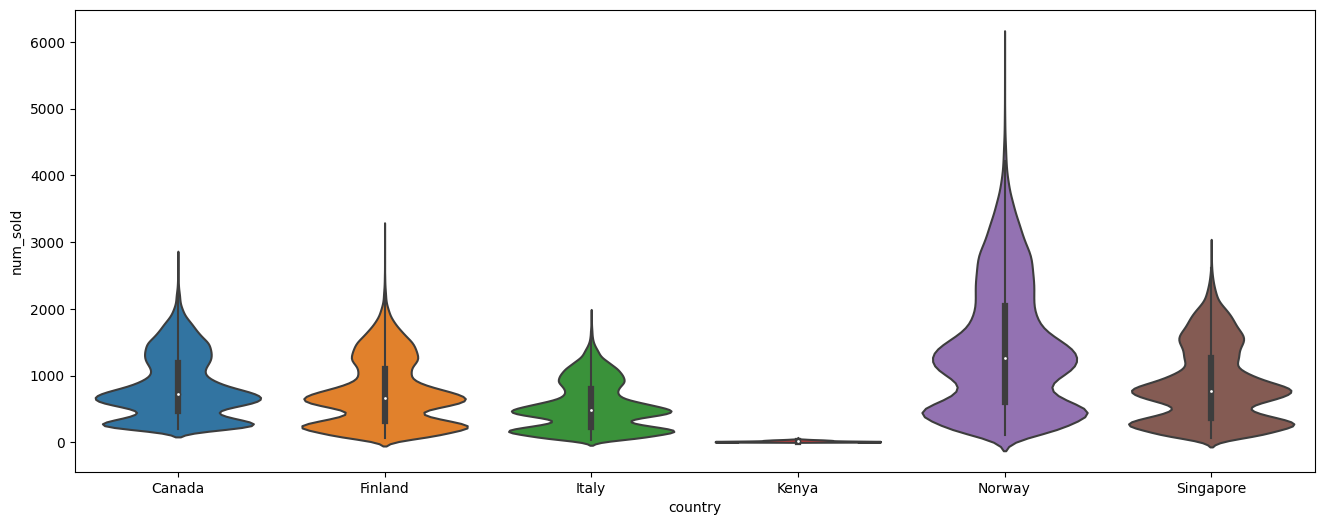

In [11]:
plt.figure(figsize=(16, 6))

sns.violinplot(x='country', y='num_sold', data=train_df, scale='width')

plt.show()

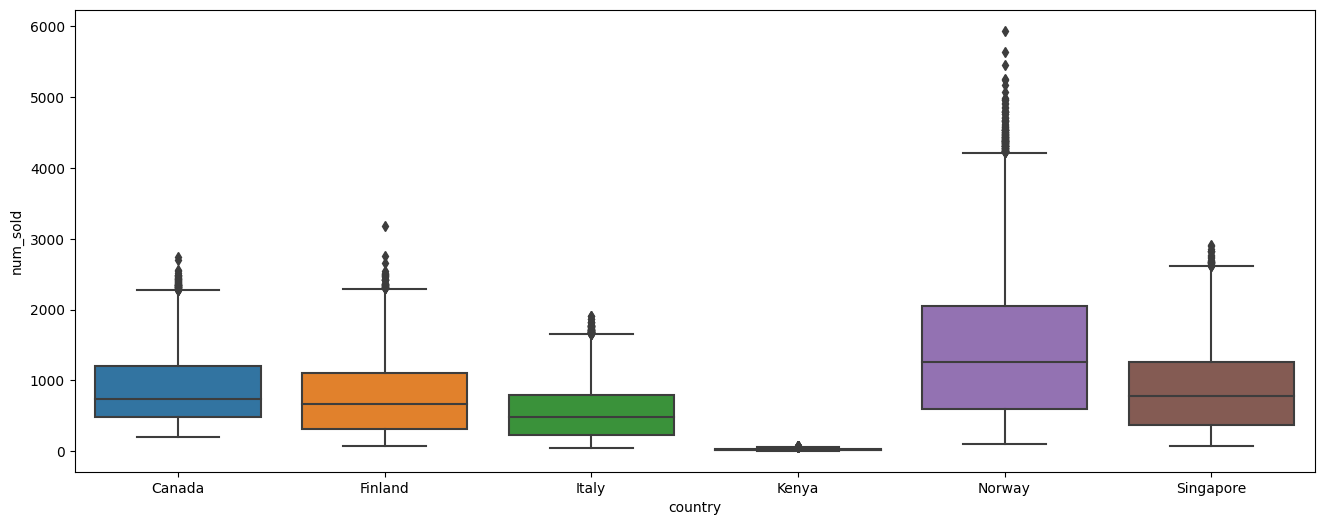

In [12]:
plt.figure(figsize=(16, 6))

sns.boxplot(x='country', y='num_sold', data=train_df)

plt.show()

In [13]:
train_df["store"].value_counts()

store
Discount Stickers       76710
Stickers for Less       76710
Premium Sticker Mart    76710
Name: count, dtype: int64

In [14]:
train_df.groupby('store')['num_sold'].sum()

store
Discount Stickers       30599237.0
Premium Sticker Mart    73703822.0
Stickers for Less       62200397.0
Name: num_sold, dtype: float64

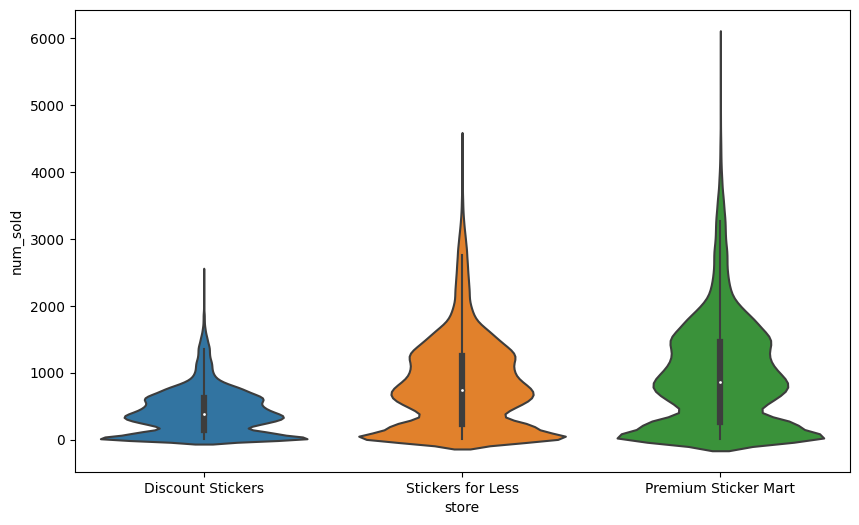

In [15]:
plt.figure(figsize=(10, 6))

sns.violinplot(x='store', y='num_sold', data=train_df, scale='width')

plt.show()

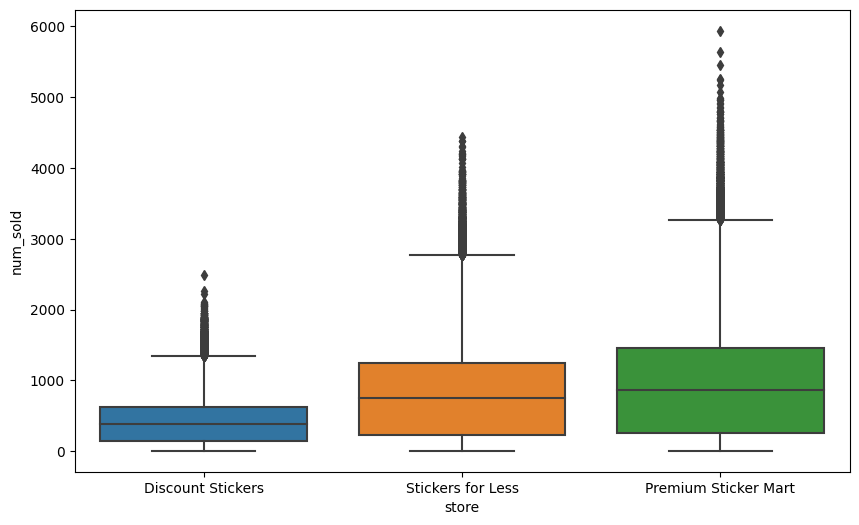

In [16]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='store', y='num_sold', data=train_df)

plt.show()

In [17]:
train_df["product"].value_counts()

product
Holographic Goose     46026
Kaggle                46026
Kaggle Tiers          46026
Kerneler              46026
Kerneler Dark Mode    46026
Name: count, dtype: int64

In [18]:
train_df.groupby('product')['num_sold'].sum()

product
Holographic Goose      7350368.0
Kaggle                56721733.0
Kaggle Tiers          46870306.0
Kerneler              25596840.0
Kerneler Dark Mode    29964209.0
Name: num_sold, dtype: float64

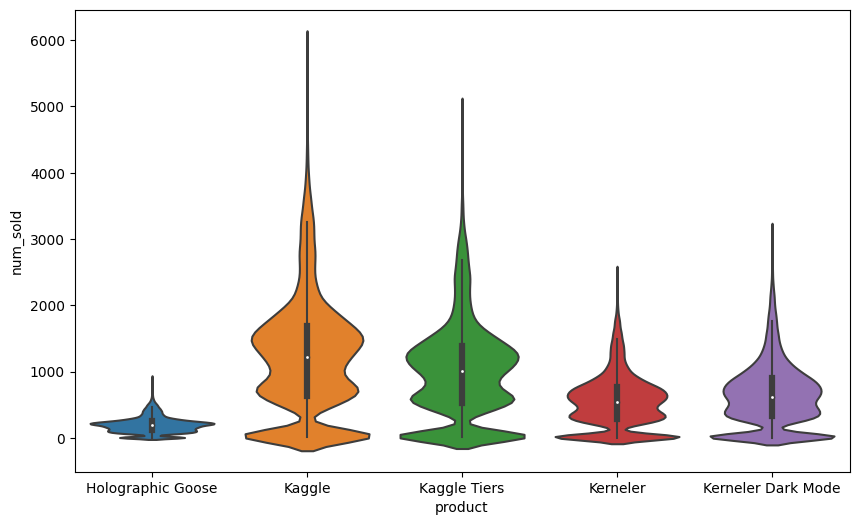

In [19]:
plt.figure(figsize=(10, 6))

sns.violinplot(x='product', y='num_sold', data=train_df, scale='width')

plt.show()

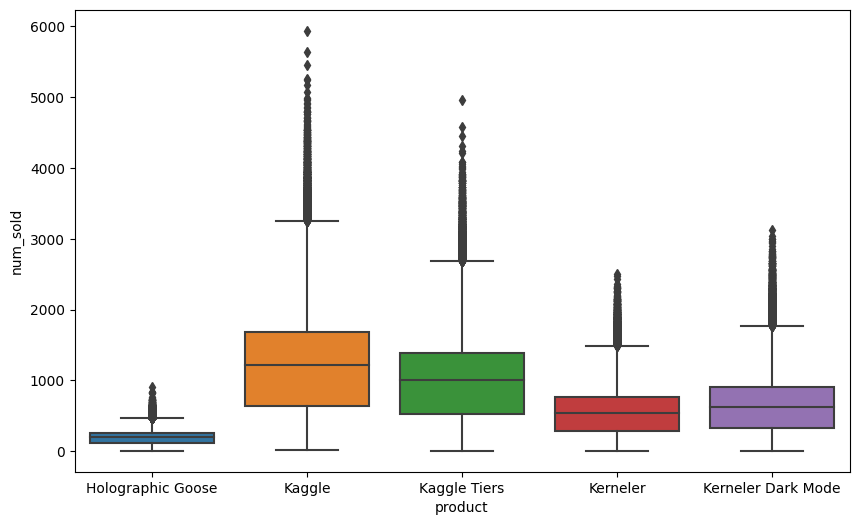

In [20]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='product', y='num_sold', data=train_df)

plt.show()

The variables country, store and product are categorical nominal variables.

The variable country has 6 levels, store has 3 levels and product has 5 levels

# NAs

<Axes: xlabel='product', ylabel='country'>

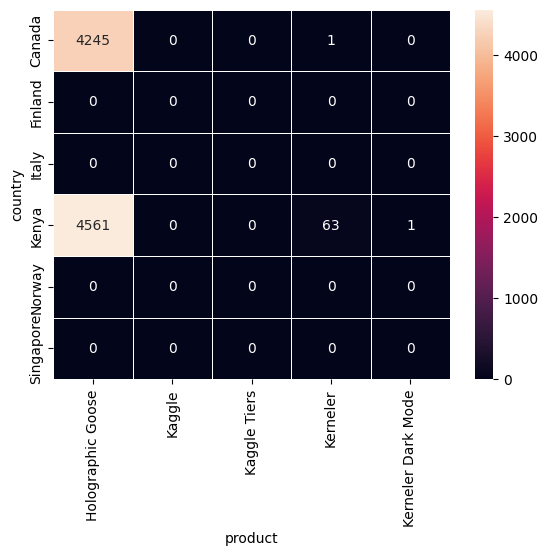

In [21]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['product'],  
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)


<Axes: xlabel='store', ylabel='country'>

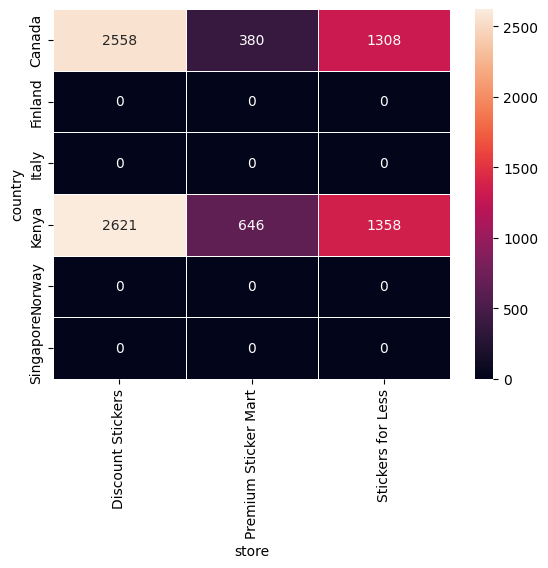

In [22]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['store'],  
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)


<Axes: xlabel='product', ylabel='store'>

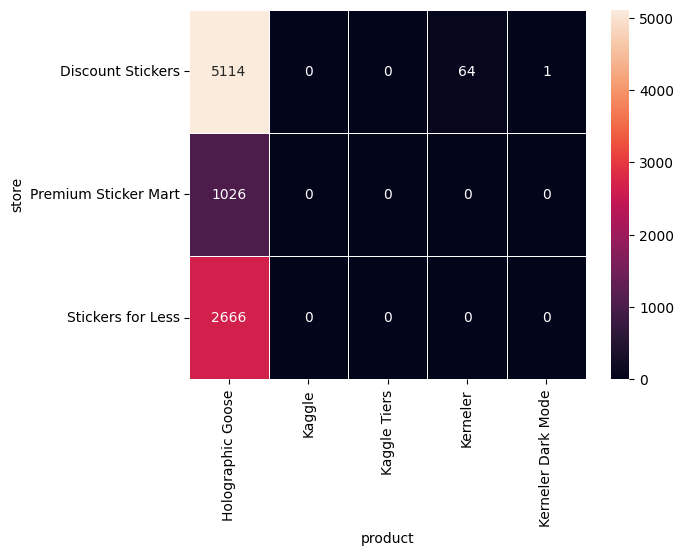

In [23]:
nas_matrix = pd.crosstab(
    index=train_df['store'],
    columns=train_df['product'],  
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)


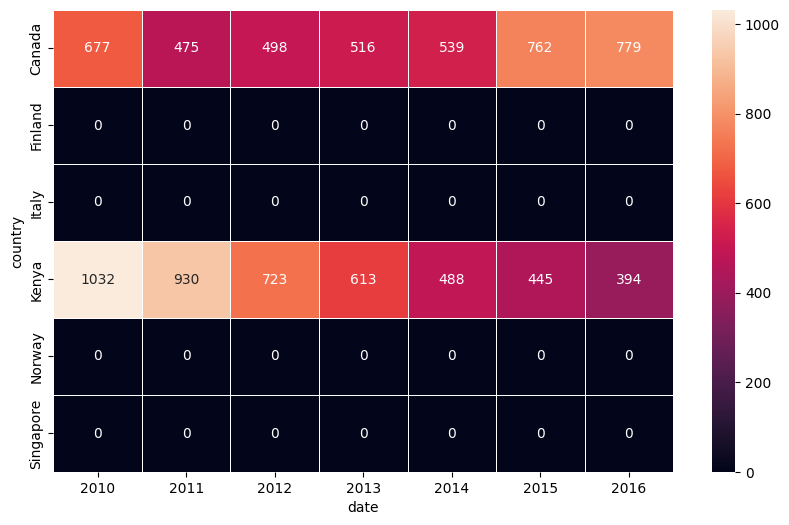

In [24]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['date'].dt.year,
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)
plt.figure(figsize=(10, 6))

sns.heatmap(
    nas_matrix,
    annot=True,
    fmt='g',
    linewidths=0.5,
)
plt.show()

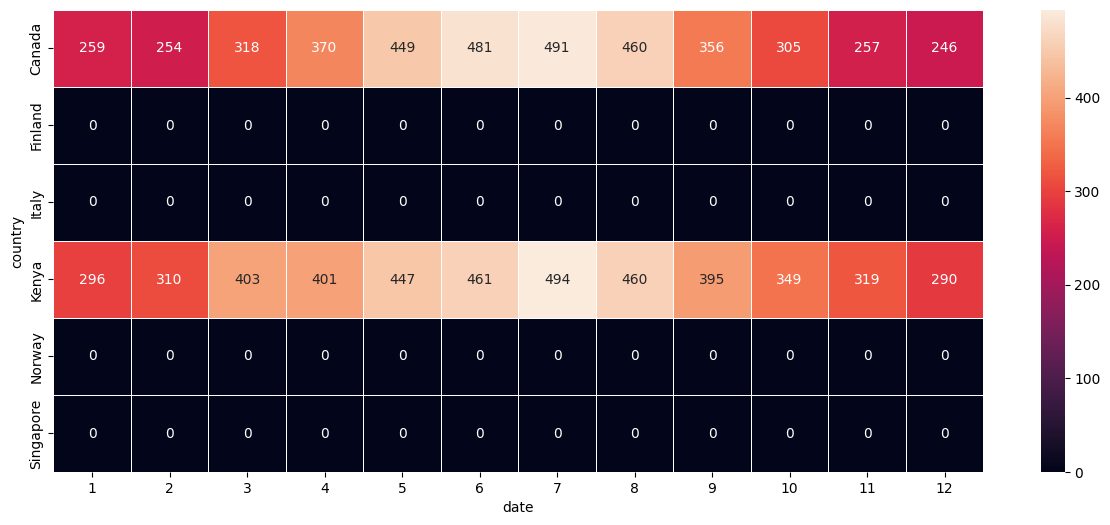

In [25]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['date'].dt.month,
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)
plt.figure(figsize=(15, 6))
sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)
plt.show()

It seems that there is a patron in the data loss Canda and Kenya had lost the same product (holographic goose). The store which had lost more data is Discount Stickers followed by Stickers for Less and Premium Sticker Mart. There also seems to be a patron with year, where first years of data get more lost.

We are going to look closer to Canada and Kenya

In [26]:
df_Canada = train_df[train_df['country']=='Canada'].copy()
df_Kenya = train_df[train_df['country']=='Kenya'].copy()

<Axes: xlabel='product', ylabel='store'>

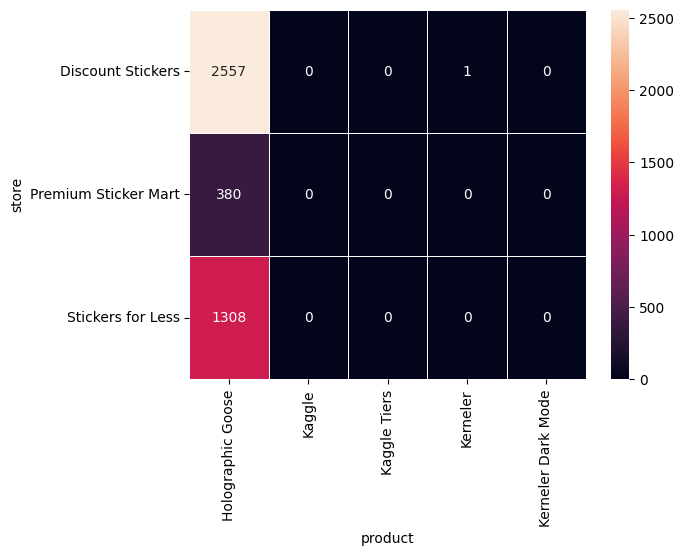

In [27]:
nas_matrix = pd.crosstab(
    index=df_Canada['store'],
    columns=df_Canada['product'],  
    values=df_Canada['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)

<Axes: xlabel='product', ylabel='store'>

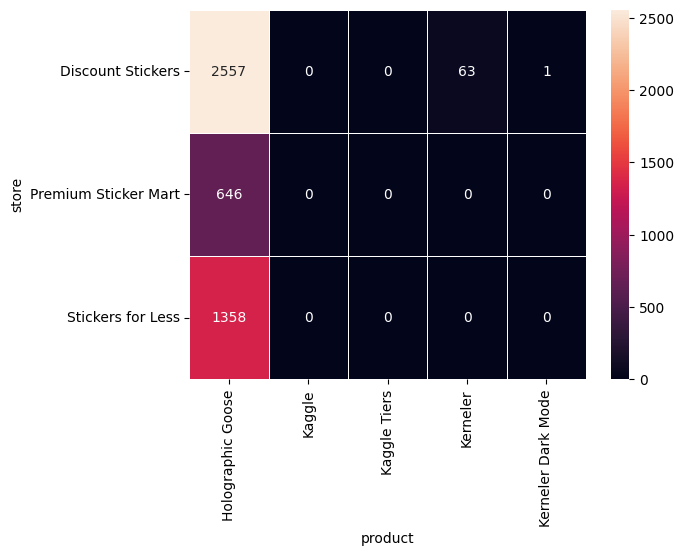

In [28]:
nas_matrix = pd.crosstab(
    index=df_Kenya['store'],
    columns=df_Kenya['product'],  
    values=df_Kenya['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)

In [29]:
group_means = train_df.groupby(['product', 'country','store'])['num_sold'].mean().to_dict()
group_means

{('Holographic Goose', 'Canada', 'Discount Stickers'): nan,
 ('Holographic Goose', 'Canada', 'Premium Sticker Mart'): 248.3821773082223,
 ('Holographic Goose', 'Canada', 'Stickers for Less'): 228.8166533226581,
 ('Holographic Goose', 'Finland', 'Discount Stickers'): 98.00156433320298,
 ('Holographic Goose', 'Finland', 'Premium Sticker Mart'): 235.26046147829487,
 ('Holographic Goose', 'Finland', 'Stickers for Less'): 198.95580758701604,
 ('Holographic Goose', 'Italy', 'Discount Stickers'): 70.84630426280798,
 ('Holographic Goose', 'Italy', 'Premium Sticker Mart'): 170.38287055142746,
 ('Holographic Goose', 'Italy', 'Stickers for Less'): 144.0183809151349,
 ('Holographic Goose', 'Kenya', 'Discount Stickers'): nan,
 ('Holographic Goose', 'Kenya', 'Premium Sticker Mart'): 5.941915227629513,
 ('Holographic Goose', 'Kenya', 'Stickers for Less'): 5.470391993327773,
 ('Holographic Goose', 'Norway', 'Discount Stickers'): 186.7258506061791,
 ('Holographic Goose', 'Norway', 'Premium Sticker Mart

In [30]:
count_grupo = train_df.groupby(['product', 'country','store'])['num_sold'].count().to_dict()
count_grupo

{('Holographic Goose', 'Canada', 'Discount Stickers'): 0,
 ('Holographic Goose', 'Canada', 'Premium Sticker Mart'): 2177,
 ('Holographic Goose', 'Canada', 'Stickers for Less'): 1249,
 ('Holographic Goose', 'Finland', 'Discount Stickers'): 2557,
 ('Holographic Goose', 'Finland', 'Premium Sticker Mart'): 2557,
 ('Holographic Goose', 'Finland', 'Stickers for Less'): 2557,
 ('Holographic Goose', 'Italy', 'Discount Stickers'): 2557,
 ('Holographic Goose', 'Italy', 'Premium Sticker Mart'): 2557,
 ('Holographic Goose', 'Italy', 'Stickers for Less'): 2557,
 ('Holographic Goose', 'Kenya', 'Discount Stickers'): 0,
 ('Holographic Goose', 'Kenya', 'Premium Sticker Mart'): 1911,
 ('Holographic Goose', 'Kenya', 'Stickers for Less'): 1199,
 ('Holographic Goose', 'Norway', 'Discount Stickers'): 2557,
 ('Holographic Goose', 'Norway', 'Premium Sticker Mart'): 2557,
 ('Holographic Goose', 'Norway', 'Stickers for Less'): 2557,
 ('Holographic Goose', 'Singapore', 'Discount Stickers'): 2557,
 ('Holographic 

In [31]:
zero_df = (train_df['num_sold']==0).sum()
zero_df

0

There are two groups with no means. meaning there is no value. Probably the NAs are 0 due to the fact that there is not 0 value. So we are going to imputate with 0

In [32]:
train_df.duplicated().sum()

0

In [33]:
# Solve the NAs problems on X data
train_df_without_na=train_df.fillna(0)

# Outliers

<Axes: ylabel='num_sold'>

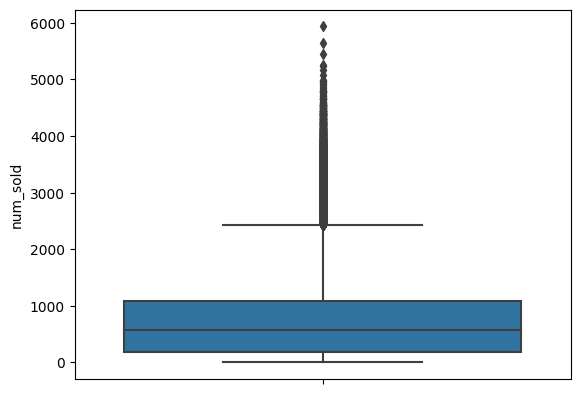

In [34]:
sns.boxplot(data=train_df_without_na, y="num_sold")

# DATA transformation

In [35]:
# See which columns are type categorical and store them
s = (train_df_without_na.dtypes == 'object')
object_cols = list(s[s].index)
print(f"Categorical variables:\n{object_cols}")

Categorical variables:
['country', 'store', 'product']


In [36]:
split_date = '2014-01-02'

data_train = train_df_without_na.copy()
data_train = data_train.sort_values('id')

split_train = data_train[data_train['date'] < split_date]
split_val = data_train[data_train['date'] >= split_date]

In [37]:
from sklearn.model_selection import TimeSeriesSplit

def target_encode_group_oof(
    df, group_cols, target_col,
    n_splits=5, smoothing=10
):
    df = df.sort_values('date').copy()

    tscv = TimeSeriesSplit(n_splits=n_splits)

    encoded = pd.Series(index=df.index, dtype=float)
    global_mean = df[target_col].mean()

    for train_idx, val_idx in tscv.split(df):

        fold_train = df.iloc[train_idx]
        fold_val = df.iloc[val_idx]

        means = fold_train.groupby(group_cols)[target_col].mean()
        counts = fold_train.groupby(group_cols)[target_col].count()

        smoothed = (means * counts + global_mean * smoothing) / (counts + smoothing)

        val_keys = fold_val[group_cols].apply(tuple, axis=1)

        encoded.loc[fold_val.index] = (val_keys.map(smoothed.to_dict()))

    return encoded.fillna(global_mean)

X_train_tar = split_train.copy()
X_test_tar = test_df.copy() 
X_val_tar = split_val.copy()


global_mean = X_train_tar['num_sold'].mean()

# Interaction encodings
X_train_tar['country_store_encoded'] = target_encode_group_oof(
    X_train_tar, ['country', 'store'], 'num_sold'
)
X_train_tar['store_product_encoded'] = target_encode_group_oof(
    X_train_tar, ['store', 'product'], 'num_sold'
)
X_train_tar['country_product_encoded'] = target_encode_group_oof(
    X_train_tar, ['country', 'product'], 'num_sold'
)

X_train_tar['country_store_product_encoded'] = target_encode_group_oof(
    X_train_tar, ['country', 'store', 'product'], 'num_sold', smoothing=20 
)
def build_group_encoding_map(df, group_cols, target_col, smoothing, global_mean):
    means = df.groupby(group_cols)[target_col].mean()
    counts = df.groupby(group_cols)[target_col].count()
    return (means * counts + global_mean * smoothing) / (counts + smoothing)

cs_map = build_group_encoding_map(X_train_tar, ['country', 'store'], 'num_sold', 20, global_mean)
sp_map = build_group_encoding_map(X_train_tar, ['store', 'product'], 'num_sold', 20, global_mean)
cp_map = build_group_encoding_map(X_train_tar, ['country', 'product'], 'num_sold', 20, global_mean)
csp_map = build_group_encoding_map(X_train_tar, ['country', 'store', 'product'], 'num_sold', 20, global_mean)

X_test_tar['country_store_encoded'] = X_test_tar[['country', 'store']].apply(tuple, axis=1).map(cs_map).fillna(global_mean)
X_test_tar['store_product_encoded'] = X_test_tar[['store', 'product']].apply(tuple, axis=1).map(sp_map).fillna(global_mean)
X_test_tar['country_product_encoded'] = X_test_tar[['country', 'product']].apply(tuple, axis=1).map(cp_map).fillna(global_mean)
X_test_tar['country_store_product_encoded'] = X_test_tar[['country', 'store', 'product']].apply(tuple, axis=1).map(csp_map).fillna(global_mean)

X_val_tar['country_store_encoded'] = X_val_tar[['country', 'store']].apply(tuple, axis=1).map(cs_map).fillna(global_mean)
X_val_tar['store_product_encoded'] = X_val_tar[['store', 'product']].apply(tuple, axis=1).map(sp_map).fillna(global_mean)
X_val_tar['country_product_encoded'] = X_val_tar[['country', 'product']].apply(tuple, axis=1).map(cp_map).fillna(global_mean)
X_val_tar['country_store_product_encoded'] = X_val_tar[['country', 'store', 'product']].apply(tuple, axis=1).map(csp_map).fillna(global_mean)


In [38]:
from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[('target_enc', TargetEncoder(smooth='auto', target_type='continuous'), object_cols)], remainder='drop')
X_train_tar_v2 = preprocessor.fit_transform(X_train_tar.drop('num_sold', axis=1), X_train_tar['num_sold'])
X_test_tar_v2 = preprocessor.transform(X_test_tar)
X_val_tar_v2 = preprocessor.transform(X_val_tar)


feature_names = preprocessor.get_feature_names_out()

X_train_tar_v2 = pd.DataFrame(
    X_train_tar_v2, 
    columns=feature_names,
    index=X_train_tar.index
).astype(float)

X_test_tar_v2 = pd.DataFrame(
    X_test_tar_v2, 
    columns=feature_names,
    index=X_test_tar.index
).astype(float)

X_val_tar_v2 = pd.DataFrame(
    X_val_tar_v2, 
    columns=feature_names,
    index=X_val_tar.index
).astype(float)

X_train_tar_v2 = X_train_tar_v2.apply(pd.to_numeric)
X_test_tar_v2 = X_test_tar_v2.apply(pd.to_numeric)
X_val_tar_v2 = X_val_tar_v2.apply(pd.to_numeric)

X_train_tarenc = pd.concat([X_train_tar, X_train_tar_v2, split_train.drop(['num_sold', 'id', 'date', 'country',
                                                                                  'store', 'product'], axis=1)], axis=1)
X_test_tarenc = pd.concat([X_test_tar, X_test_tar_v2, test_df.drop(['id', 'date', 'country', 'store', 'product'], axis=1)], axis=1)

X_val_tarenc = pd.concat([X_val_tar, X_val_tar_v2, split_val.drop(['num_sold', 'id', 'date', 'country',
                                                                                  'store', 'product'], axis=1)], axis=1)

print("Train DataFrame shape:", X_train_tarenc.shape)
print("Test DataFrame shape:", X_test_tarenc.shape)
print("Validation DataFrame shape:", X_val_tarenc.shape)


Train DataFrame shape: (131580, 13)
Test DataFrame shape: (98550, 12)
Validation DataFrame shape: (98550, 13)


In [39]:
#Create a new column to differentiate the three dataFrame and join them
X_train_tarenc['df'] = 'train'
X_test_tarenc['df'] = 'test'
X_val_tarenc['df'] = 'val'
df_merged = pd.concat([X_train_tarenc, X_test_tarenc,X_val_tarenc], ignore_index=True)
df_merged = df_merged.reset_index(drop=True)

#add a time-step feature 
df_merged = df_merged.sort_values(['country', 'store', 'product', 'date'])
df_merged['Time'] = df_merged.groupby(['country', 'store', 'product']).cumcount() 

#Use the function create_features to get time features
df_merged = create_features(df_merged)

df_merged.shape

(328680, 22)

In [40]:
# see new dataframe columns
print(f"Dataframe columns:\n{df_merged.columns}")

Dataframe columns:
Index(['id', 'date', 'country', 'store', 'product', 'num_sold',
       'country_store_encoded', 'store_product_encoded',
       'country_product_encoded', 'country_store_product_encoded',
       'target_enc__country', 'target_enc__store', 'target_enc__product', 'df',
       'Time', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear'],
      dtype='object')


In [41]:
# set variable y and x for the training data
df_merged=df_merged.sort_values(by='id')
y_train = df_merged[df_merged['df']=='train'].num_sold
y_val = df_merged[df_merged['df']=='val'].num_sold
df_x = df_merged.drop('num_sold', axis=1).copy()

In [42]:
#Transforming the categorical variables from the test and training data into numerical
import sklearn
from sklearn.preprocessing import OneHotEncoder
OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, feature_name_combiner='concat')
OH_array  = OH_encoder.fit_transform(df_x[object_cols])
OH_cols_df = pd.DataFrame(OH_array, columns=OH_encoder.get_feature_names_out(object_cols), index=df_x.index
)
OH_cols_df

,country_Canada,country_Finland,country_Italy,country_Kenya,country_Norway,country_Singapore,store_Discount Stickers,store_Premium Sticker Mart,store_Stickers for Less,product_Holographic Goose,product_Kaggle,product_Kaggle Tiers,product_Kerneler,product_Kerneler Dark Mode
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230125,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
230126,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
230127,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
230128,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [43]:
#Merge the categorical variables with the other variables
OH_cols_df.index = df_x.index

num_x_df = df_x.drop(object_cols, axis=1)

OH_x_df = pd.concat([num_x_df, OH_cols_df], axis=1)

OH_x_df.columns = OH_x_df.columns.astype(str)

OH_x_df.columns

Index(['id', 'date', 'country_store_encoded', 'store_product_encoded',
       'country_product_encoded', 'country_store_product_encoded',
       'target_enc__country', 'target_enc__store', 'target_enc__product', 'df',
       'Time', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear', 'country_Canada', 'country_Finland',
       'country_Italy', 'country_Kenya', 'country_Norway', 'country_Singapore',
       'store_Discount Stickers', 'store_Premium Sticker Mart',
       'store_Stickers for Less', 'product_Holographic Goose',
       'product_Kaggle', 'product_Kaggle Tiers', 'product_Kerneler',
       'product_Kerneler Dark Mode'],
      dtype='object')

In [44]:
#Make sure there isn't no NAs
print(f"NAs num_sold: {y_train.isnull().sum()} \n\n NAs varialbes: \n{OH_x_df.isnull().sum()}")


NAs num_sold: 0 

 NAs varialbes: 
id                               0
date                             0
country_store_encoded            0
store_product_encoded            0
country_product_encoded          0
country_store_product_encoded    0
target_enc__country              0
target_enc__store                0
target_enc__product              0
df                               0
Time                             0
dayofweek                        0
quarter                          0
month                            0
year                             0
dayofyear                        0
dayofmonth                       0
weekofyear                       0
country_Canada                   0
country_Finland                  0
country_Italy                    0
country_Kenya                    0
country_Norway                   0
country_Singapore                0
store_Discount Stickers          0
store_Premium Sticker Mart       0
store_Stickers for Less          0
product_Holographic 

In [45]:
#Separate the test data and training data
X_train = OH_x_df[OH_x_df['df']=='train'].drop(['id', 'df', 'date'], axis=1).copy()
X_test = OH_x_df[OH_x_df['df']=='test'].drop(['id', 'df', 'date'], axis=1).copy()
X_val = OH_x_df[OH_x_df['df']=='val'].drop(['id', 'df', 'date'], axis=1).copy()

In [46]:
import joblib
import json
import optuna
import optuna.visualization as vis
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error, root_mean_squared_error,
    root_mean_squared_log_error
)
from sklearn.model_selection import cross_val_score, learning_curve, TimeSeriesSplit
from optuna.pruners import MedianPruner
from functools import partial

# Kaggle directory for saving files
Output_directory= '/kaggle/working/'

# Save dataframes
X_train.to_parquet(f'{Output_directory}X_train.parquet')
X_test.to_parquet(f'{Output_directory}X_test.parquet')
X_val.to_parquet(f'{Output_directory}X_val.parquet')
y_train.to_frame(name='sales').to_parquet(f'{Output_directory}y_train.parquet')
y_val.to_frame(name='sales').to_parquet(f'{Output_directory}y_val.parquet')

# Time-based validation: respects chronological order, never validates on data prior to that fold's train set
tscv = TimeSeriesSplit(n_splits=5)
    
# Pruner
pruner = MedianPruner(
    n_startup_trials=8,
    n_warmup_steps=2,
    interval_steps=1,
    n_min_trials=8,
)

# Early stopping: stops the whole study if the best value hasn't improved in the last `patience` trials
def early_stopping(study, trial, patience=30, start_trial_number=0):
    trials_since_start = trial.number - start_trial_number
    if trials_since_start < patience:
        return

    best_trial_number = study.best_trial.number
    if best_trial_number < start_trial_number:
        trials_without_improvement = trials_since_start
    else:
        trials_without_improvement = trial.number - best_trial_number

    if trials_without_improvement >= patience:
        print(f"No improvement in the last {patience} trials. Stopping study.")
        study.stop()
#Sampler with seed for every model
sampler= optuna.samplers.TPESampler(seed=42)

#####################################################################
# METRICS
#####################################################################

def cross_val(model, X_train, y_train, name=""):
    scores = -cross_val_score(model, X_train, y_train, cv=tscv, scoring='neg_root_mean_squared_error')
    print(f"--- {name}: Cross-validation (5 folds) ---")
    print(f"RMSE por fold: {np.round(scores, 4)}")
    print(f"Media: {scores.mean():.4f} | Std: {scores.std():.4f} | CV%: {scores.std()/scores.mean()*100:.2f}%")
    return {'cv_mean': scores.mean(), 'cv_std': scores.std()}
def cross_val_xgb(params, X, y, tscv):
    scores = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):

        X_tr = X.iloc[train_idx]
        X_va = X.iloc[val_idx]
        y_tr = y.iloc[train_idx]
        y_va = y.iloc[val_idx]

        model = xgb.XGBRegressor(
            **params,
            random_state=42,
            early_stopping_rounds=30
        )

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False
        )

        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        scores.append(rmse)

        print(f"Fold {fold + 1}: {rmse:.4f}")

    print(f"CV mean: {np.mean(scores):.4f}")
    print(f"CV std: {np.std(scores):.4f}")

    return np.array(scores)
def plot_learning_curve(model, X_train, y_train, name=""):

    model_lc = xgb.XGBRegressor(
        **model.get_params()
    )

    # Remove early stopping
    model_lc.set_params(early_stopping_rounds=None)

    train_sizes, train_scores, val_scores = learning_curve(
        model_lc,
        X_train,
        y_train,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_rmse = -train_scores.mean(axis=1)
    val_rmse = -val_scores.mean(axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_rmse, label="Train RMSE")
    plt.plot(train_sizes, val_rmse, label="Validation RMSE")
    plt.xlabel("Training samples")
    plt.ylabel("RMSE")
    plt.title(f"Learning Curve - {name}")
    plt.legend()
    plt.show()
def evaluate_additional_metrics(y_true, y_pred, name=""):
    errors = y_true - y_pred
    error_pct = np.abs(errors / y_true) * 100

    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape_val = mean_absolute_percentage_error(y_true, y_pred) * 100
    try:
        rmsle = root_mean_squared_log_error(y_true, y_pred)
    except ValueError:
        rmsle = None  # fails if there are negative predictions

    print(f"--- {name}: Additional metrics ---")
    print(f"MAE: {mae:.4f} | MAPE: {mape_val:.2f}% | R²: {r2:.4f}", end="")
    print(f" | RMSLE: {rmsle:.4f}" if rmsle is not None else " | RMSLE: N/A (negative predictions)")
    print(f"Bias (mean error): {errors.mean():.4f}")
    print(f"Prediction std: {y_pred.std():.4f} | Real std: {y_true.std():.4f}")
    for tol in [10, 15, 20]:
        successes = (error_pct <= tol).mean() * 100
        print(f"Within ±{tol}%: {successes:.2f}%")
        
def evaluate_gap(y_train, pred_train, y_val, pred_val, name=""):
    rmse_train = root_mean_squared_error(y_train, pred_train)
    rmse_val = root_mean_squared_error(y_val, pred_val)
    gap = rmse_val - rmse_train
    gap_pct = gap / rmse_train * 100

    print(f"--- {name}: Train vs Val ---")
    print(f"RMSE train: {rmse_train:.4f} | RMSE val: {rmse_val:.4f}")
    print(f"Gap: {gap:.4f} ({gap_pct:.2f}%)")

    return {'rmse_train': rmse_train, 'rmse_val': rmse_val, 'gap_pct': gap_pct}


In [47]:
#Remove variables with high correlation
X_train = X_train.drop(['Time', 'quarter', 'dayofmonth'], axis=1).copy()


X_val = X_val.drop(['Time', 'quarter', 'dayofmonth'], axis=1).copy()

In [48]:
##############################################################
# 1. XGBoost
##############################################################
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 100),
        'gamma': trial.suggest_float('gamma', 0.01, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.2, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 20.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 10, 100.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],verbose=False)
        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

#study_xgb = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
#study_xgb.optimize(objective_xgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
#print(f"XGBoost best parameters: {study_xgb.best_params}")

#saves the study
#joblib.dump(study_xgb, f'{Output_directory}study_xgb.pkl')

#Load study 
study_xgb = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/study_xgb.pkl')

In [49]:
print(f"Trials executed: {len(study_xgb.trials)}")
print(f"Best trial: {study_xgb.best_trial.number}")
print(f"Best RMSE: {study_xgb.best_value:.4f}")
print(f"Best parameters: {study_xgb.best_params}")

Trials executed: 113
Best trial: 52
Best RMSE: 115.2392
Best parameters: {'n_estimators': 2908, 'learning_rate': 0.1485824905408842, 'max_depth': 4, 'min_child_weight': 67, 'gamma': 4.4439707383752864, 'subsample': 0.8267445557527602, 'colsample_bytree': 0.6207994620829045, 'colsample_bylevel': 0.33535703198481825, 'reg_alpha': 0.012468239299497957, 'reg_lambda': 19.280058201680067}


In [50]:
df_trials_xgb = study_xgb.trials_dataframe()
print(df_trials_xgb[['number', 'value','state']].tail(15))

     number       value     state
98       98  130.004945    PRUNED
99       99  131.157062    PRUNED
100     100  128.862766    PRUNED
101     101  117.052417    PRUNED
102     102  129.474078    PRUNED
103     103  116.286422  COMPLETE
104     104  129.675847    PRUNED
105     105  129.930315    PRUNED
106     106  128.703506    PRUNED
107     107  115.607000  COMPLETE
108     108  130.862083    PRUNED
109     109  116.346846  COMPLETE
110     110  116.179697  COMPLETE
111     111  117.180772    PRUNED
112     112  116.740323  COMPLETE


In [51]:
vis.plot_optimization_history(study_xgb).show()
vis.plot_param_importances(study_xgb).show()

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning:

invalid value encountered in less



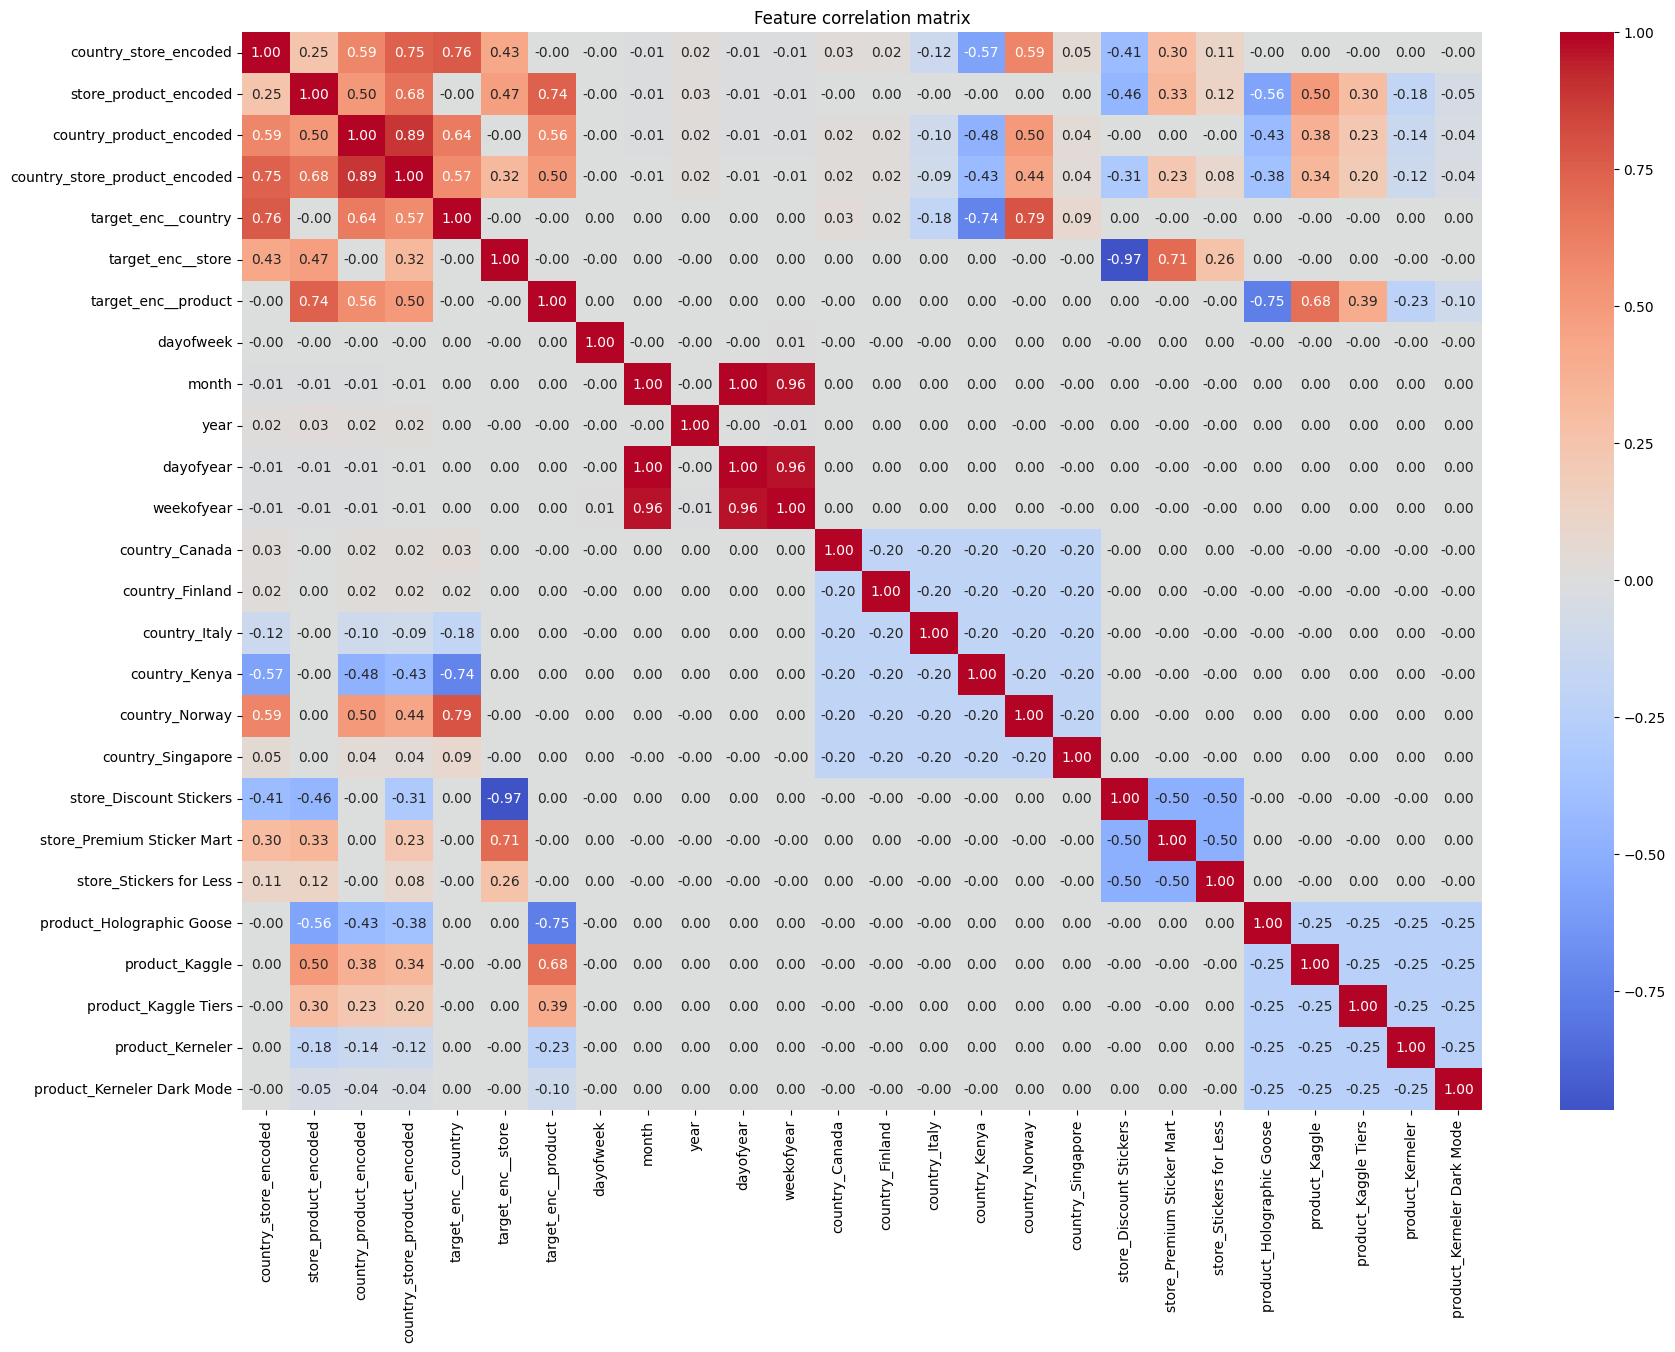

In [52]:
# Autocorrelation matrix
corr_matrix = X_train.corr()

plt.figure(figsize=(20, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,  fmt='.2f', annot=True)
plt.title('Feature correlation matrix')
plt.show()


In [53]:
#Creat a dataframe to fit de model with the best params
# 80% for training
split = int(len(X_train) * 0.8)

df_train = X_train.iloc[:split].copy()
y_tr = y_train.iloc[:split].copy()

# 20% early stopping
df_val = X_train.iloc[split:].copy()
y_va = y_train.iloc[split:].copy()   

#model_xgb = xgb.XGBRegressor(**study_xgb.best_params, random_state=42, early_stopping_rounds=30)
#model_xgb.fit(df_train, y_tr, eval_set=[(df_val, y_va)],verbose=False)
#joblib.dump(model_xgb, f'{Output_directory}model_xgb.pkl')

#Load study 
model_xgb = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/model_xgb.pkl')

--- XGBoost: Train vs Val ---
RMSE train: 292.1420 | RMSE val: 185.8386
Gap: -106.3033 (-36.39%)
--- XGBoost: Additional metrics ---
MAE: 103.2194 | MAPE: 921511826895426176.00% | R²: 0.9162 | RMSLE: N/A (negative predictions)
Bias (mean error): -62.4591
Prediction std: 726.0214 | Real std: 641.8150
Within ±10%: 39.97%
Within ±15%: 54.03%
Within ±20%: 63.48%
Fold 1: 159.0684
Fold 2: 140.9593
Fold 3: 143.8414
Fold 4: 115.1670
Fold 5: 105.2307
CV mean: 132.8533
CV std: 19.7458


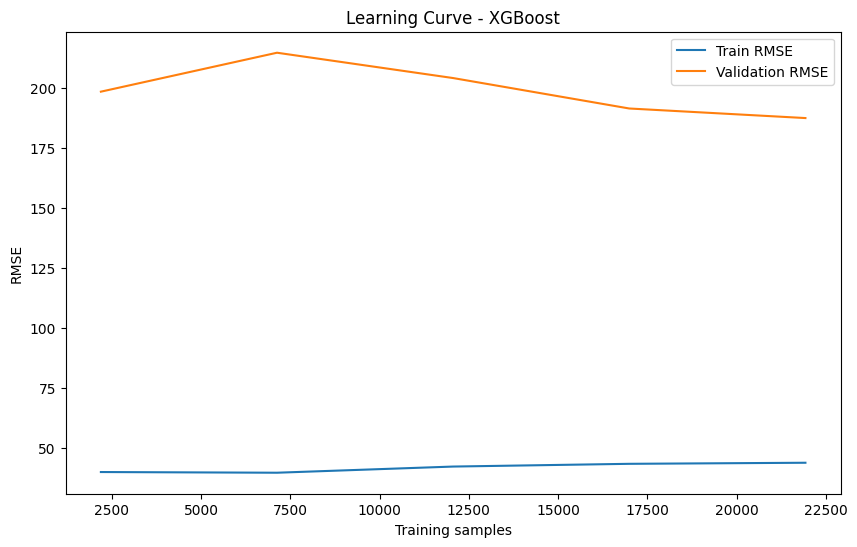

In [54]:
pred_train_xgb = model_xgb.predict(X_train)
pred_val_xgb = model_xgb.predict(X_val)
gap_xgb = evaluate_gap(y_train, pred_train_xgb, y_val, pred_val_xgb, "XGBoost")
addmet_xgb_trget = evaluate_additional_metrics(y_val, pred_val_xgb, "XGBoost")
cv_xgb = cross_val_xgb(
    study_xgb.best_params,
    X_train,
    y_train,
    tscv)
plot_learning_curve(model_xgb, X_train, y_train, "XGBoost")


In [55]:
results = pd.DataFrame({
    'date': data_train.loc[data_train['date'] >= split_date, 'date'].values,
    'y_true': y_val.values,
    'y_pred': pred_val_xgb
})

results['year'] = results['date'].dt.year

rmse_by_year = (
    results.groupby('year')
    .apply(lambda x: root_mean_squared_error(x['y_true'], x['y_pred']))
)

print(rmse_by_year)

year
2014     93.740378
2015    198.025576
2016    235.539140
dtype: float64


<ipython-input-55-38f075c88f8d>:11: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [56]:
print(
    results.groupby('year')['y_true']
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
)

            mean  median         std  min     max  count
year                                                    
2014  747.661844   600.0  706.087613  0.0  5643.0  32760
2015  666.152390   526.0  619.874054  0.0  3996.0  32850
2016  653.438767   528.0  590.076990  0.0  3466.0  32940


In [57]:
print(
    results.groupby('year')['y_pred']
    .agg(['mean', 'median', 'std', 'min', 'max'])
)

            mean      median         std        min          max
year                                                            
2014  750.727356  603.401917  725.253357 -50.092033  4380.856445
2015  751.604065  604.326843  726.025330 -50.092033  4208.538086
2016  752.037048  604.326843  726.812988 -50.092033  4387.898438


In [58]:
from sklearn.inspection import permutation_importance

#perm = permutation_importance(model_xgb, X_val, y_val, random_state=42, n_repeats=10)
#Load study 
perm = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/permutation_result.pkl')
feature_importances = pd.DataFrame({
    'feature': X_val.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values(by='importance_mean', ascending=False)

#joblib.dump(perm, f'{Output_directory}permutation_result.pkl')

print(feature_importances)

                          feature  importance_mean  importance_std
3   country_store_product_encoded         0.255773        0.000790
2         country_product_encoded         0.082511        0.000447
7                       dayofweek         0.028770        0.000513
1           store_product_encoded         0.008888        0.000539
23           product_Kaggle Tiers         0.004659        0.000089
8                           month         0.004383        0.000076
10                      dayofyear         0.003398        0.000087
11                     weekofyear         0.003325        0.000069
25     product_Kerneler Dark Mode         0.003318        0.000028
17              country_Singapore         0.001361        0.000017
24               product_Kerneler         0.000924        0.000009
20        store_Stickers for Less         0.000184        0.000013
13                country_Finland         0.000052        0.000001
14                  country_Italy         0.000020        0.00

In [59]:
import shap

SAMPLE_SIZE = 5000
X_train_sample = X_train.sample(n=SAMPLE_SIZE, random_state=42)

explainer_lgb = shap.TreeExplainer(model_xgb)
shap_values_lgb = explainer_lgb.shap_values(X_train_sample, check_additivity=False)

shap_lgb = pd.DataFrame({
    'feature': X_train_sample.columns,
    'mean_abs_shap': np.abs(shap_values_lgb).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_lgb['pct'] = shap_lgb['mean_abs_shap'] / shap_lgb['mean_abs_shap'].sum() * 100

print(shap_lgb)

# Flag features below a threshold as candidates for removal
UMBRAL_PCT = 0.5  # adjust as needed

candidatas_a_eliminar = shap_lgb[shap_lgb['pct'] < UMBRAL_PCT]['feature'].tolist()
print(f"\nCandidate features to drop (< {UMBRAL_PCT}% of total importance):")
print(candidatas_a_eliminar)

                          feature  mean_abs_shap        pct
0   country_store_product_encoded     169.019760  24.232895
1         country_product_encoded     126.772385  18.175756
2           store_product_encoded      59.478424   8.527609
3                       dayofweek      46.106850   6.610485
4         store_Discount Stickers      45.846607   6.573173
5             target_enc__country      45.236629   6.485719
6           country_store_encoded      43.574158   6.247365
7                            year      31.270575   4.483361
8             target_enc__product      29.243238   4.192696
9               target_enc__store      15.460987   2.216690
10                 product_Kaggle      10.911164   1.564368
11                 country_Norway      10.047884   1.440597
12                      dayofyear       7.912249   1.134404
13                     weekofyear       7.738385   1.109477
14                          month       7.595037   1.088924
15     product_Kerneler Dark Mode       

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

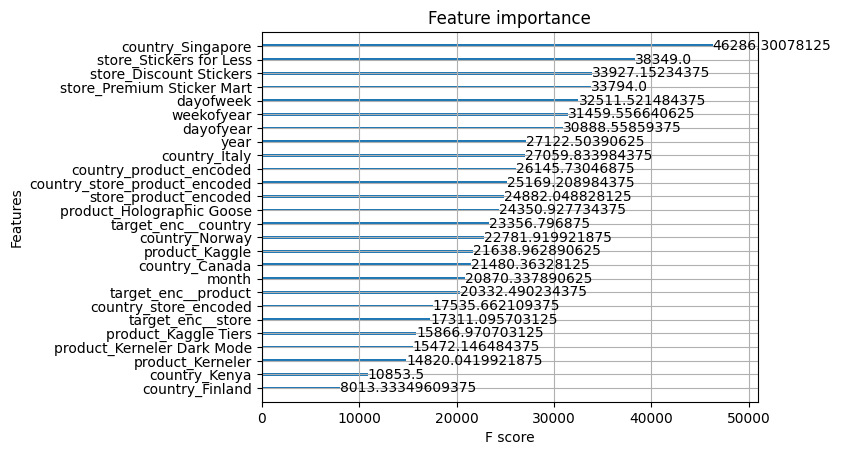

In [60]:
xgb.plot_importance(model_xgb, importance_type='cover')

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

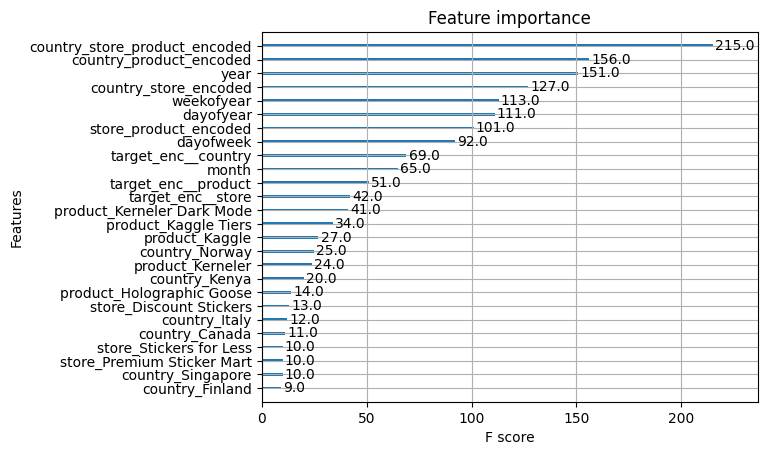

In [61]:
xgb.plot_importance(model_xgb, importance_type='weight')

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

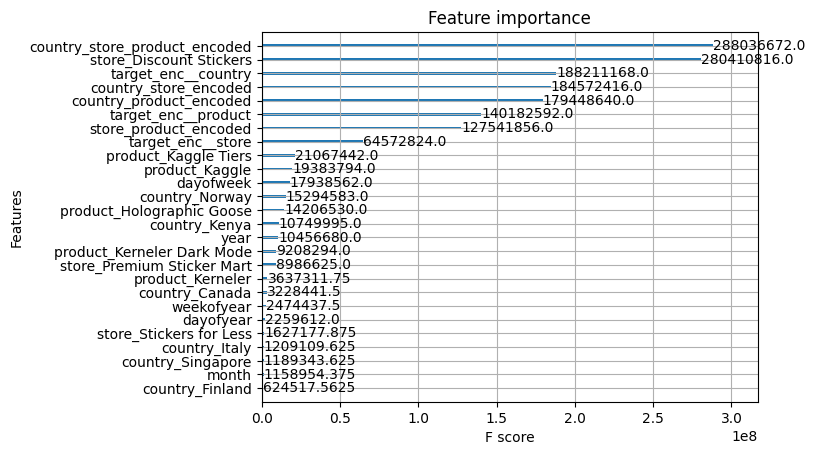

In [62]:
xgb.plot_importance(model_xgb, importance_type='gain')

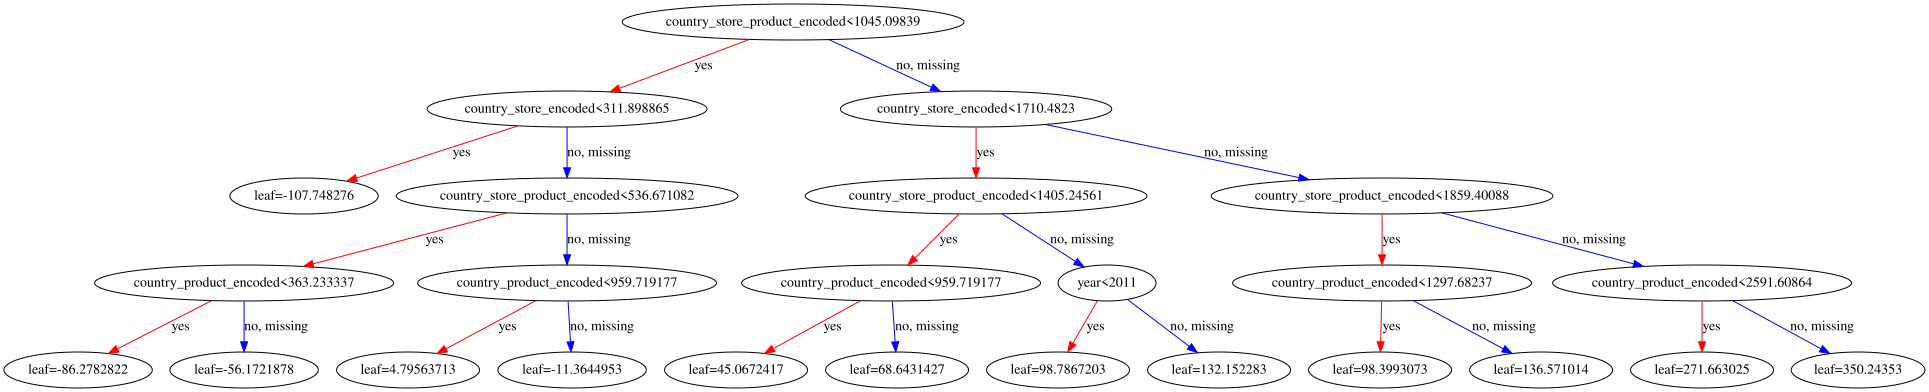

In [63]:
xgb.to_graphviz(model_xgb, num_trees=0)

In [64]:
#Target encoded dataframe
X_train_target = X_train.drop(['country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()

X_val_target = X_val.drop(['country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()
    

In [65]:
# 1. XGBoost with only target encoding 
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 100),
        'gamma': trial.suggest_float('gamma', 0.01, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.2, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 20.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 10, 100.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_target)):
        X_tr, X_va = X_train_target.iloc[train_idx], X_train_target.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

study_xgb_target = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
study_xgb_target.optimize(objective_xgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
print(f"XGBoost best parameters: {study_xgb_target.best_params}")

# saves the study
joblib.dump(study_xgb_target, f'{Output_directory}study_xgb_target.pkl')

#Load study 
#study_xgb_target = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/study_xgb_target.pkl')

[I 2026-09-17 11:10:24,953] A new study created in memory with name: no-name-d3d29dbf-4a6f-450e-b418-b5520e8f8709
[I 2026-09-17 11:10:32,164] Trial 0 finished with value: 133.17488887311256 and parameters: {'n_estimators': 1436, 'learning_rate': 0.17254716573280354, 'max_depth': 4, 'min_child_weight': 64, 'gamma': 0.02938027938703535, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.4348501673009197, 'colsample_bylevel': 0.8929409166199482, 'reg_alpha': 0.3849583075868115, 'reg_lambda': 51.059032093947565}. Best is trial 0 with value: 133.17488887311256.
[I 2026-09-17 11:10:39,053] Trial 1 finished with value: 133.84143723765538 and parameters: {'n_estimators': 551, 'learning_rate': 0.18276027831785724, 'max_depth': 5, 'min_child_weight': 29, 'gamma': 0.035113563139704075, 'subsample': 0.5917022549267169, 'colsample_bytree': 0.5825453457757226, 'colsample_bylevel': 0.6198051453057902, 'reg_alpha': 0.07207895500630218, 'reg_lambda': 19.55370866274525}. Best is trial 0 with value: 

No improvement in the last 60 trials. Stopping study.
XGBoost best parameters: {'n_estimators': 2143, 'learning_rate': 0.03214765740316156, 'max_depth': 5, 'min_child_weight': 78, 'gamma': 3.4635546739139884, 'subsample': 0.9103368708973524, 'colsample_bytree': 0.5256717325827018, 'colsample_bylevel': 0.8771769070915174, 'reg_alpha': 0.39886477098815004, 'reg_lambda': 13.285706488695984}


['/kaggle/working/study_xgb_target.pkl']

In [66]:
print(f"Trials executed: {len(study_xgb_target.trials)}")
print(f"Best trial: {study_xgb_target.best_trial.number}")
print(f"Best RMSE: {study_xgb_target.best_value:.4f}")
print(f"Best parameters: {study_xgb_target.best_params}")

Trials executed: 82
Best trial: 21
Best RMSE: 125.8943
Best parameters: {'n_estimators': 2143, 'learning_rate': 0.03214765740316156, 'max_depth': 5, 'min_child_weight': 78, 'gamma': 3.4635546739139884, 'subsample': 0.9103368708973524, 'colsample_bytree': 0.5256717325827018, 'colsample_bylevel': 0.8771769070915174, 'reg_alpha': 0.39886477098815004, 'reg_lambda': 13.285706488695984}


In [67]:
#Creat a dataframe to fit de model with the best params
# 80% for training
split = int(len(X_train_target) * 0.8)

df_train = X_train_target.iloc[:split].copy()
y_tr = y_train.iloc[:split].copy()

# 20% early stopping
df_val = X_train_target.iloc[split:].copy()
y_va = y_train.iloc[split:].copy()   

model_xgb_target = xgb.XGBRegressor(**study_xgb_target.best_params, random_state=42, early_stopping_rounds=30)
model_xgb_target.fit(df_train, y_tr, eval_set=[(df_val, y_va)],verbose=False)
joblib.dump(model_xgb_target, f'{Output_directory}model_xgb_target.pkl')

#Load study 
#model_xgb_target = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/model_xgb_target.pkl')

['/kaggle/working/model_xgb_target.pkl']

--- XGBoost: Train vs Val ---
RMSE train: 72.5205 | RMSE val: 177.9609
Gap: 105.4403 (145.39%)
--- XGBoost: Additional metrics ---
MAE: 96.0627 | MAPE: 882955859938570880.00% | R²: 0.9231 | RMSLE: N/A (negative predictions)
Bias (mean error): -59.6985
Prediction std: 720.8954 | Real std: 641.8150
Within ±10%: 44.40%
Within ±15%: 57.54%
Within ±20%: 65.68%
Fold 1: 160.6925
Fold 2: 120.9404
Fold 3: 137.4374
Fold 4: 116.1477
Fold 5: 94.2536
CV mean: 125.8943
CV std: 22.2028


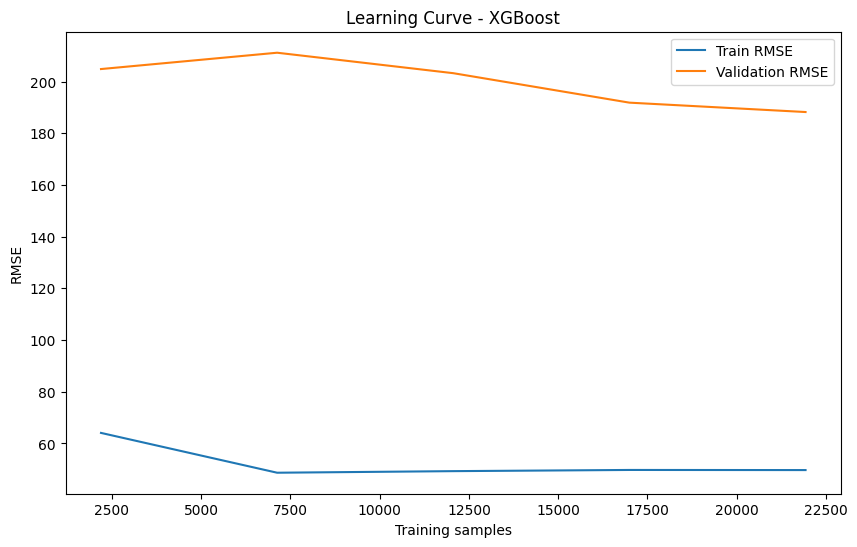

In [68]:
pred_train_xgb_target = model_xgb_target.predict(X_train_target)
pred_val_xgb_target = model_xgb_target.predict(X_val_target)
gap_xgb_target = evaluate_gap(y_train, pred_train_xgb_target, y_val, pred_val_xgb_target, "XGBoost")
addmet_xgb_target = evaluate_additional_metrics(y_val, pred_val_xgb_target, "XGBoost")
cv_xgb = cross_val_xgb(
    study_xgb_target.best_params,
    X_train_target,
    y_train,
    tscv)
plot_learning_curve(model_xgb_target, X_train_target, y_train, "XGBoost")


In [69]:
perm_xgb_target = permutation_importance(model_xgb_target, X_val_target, y_val, random_state=42, n_repeats=10)
#Load study 
#perm_xgb_target= joblib.load('/kaggle/input/datasets/davibaca/study-xgb/permutation_result_xgb_target.pkl')
feature_importances = pd.DataFrame({
    'feature': X_val_target.columns,
    'importance_mean': perm_xgb_target.importances_mean,
    'importance_std': perm_xgb_target.importances_std
}).sort_values(by='importance_mean', ascending=False)

joblib.dump(perm_xgb_target, f'{Output_directory}permutation_result_xgb_target.pkl')

print(feature_importances)

                          feature  importance_mean  importance_std
3   country_store_product_encoded         0.309258        0.001410
4             target_enc__country         0.109261        0.000875
6             target_enc__product         0.108631        0.000612
5               target_enc__store         0.030668        0.000471
7                       dayofweek         0.030528        0.000520
10                      dayofyear         0.006824        0.000155
11                     weekofyear         0.003569        0.000078
8                           month         0.001393        0.000043
9                            year         0.000000        0.000000
2         country_product_encoded        -0.000360        0.000190
0           country_store_encoded        -0.004857        0.000281
1           store_product_encoded        -0.006515        0.000358


In [70]:
# 1. XGBoost with only target encoding without second level interaction

X_train_target_wtSC = X_train.drop(['country_store_encoded', 'store_product_encoded',
                                                  'country_product_encoded','country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()

X_val_target_wtSC = X_val.drop(['country_store_encoded', 'store_product_encoded',
                                                  'country_product_encoded','country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()
    

In [71]:
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 100),
        'gamma': trial.suggest_float('gamma', 0.01, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.2, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 20.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 10, 100.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_target_wtSC)):
        X_tr, X_va = X_train_target_wtSC.iloc[train_idx], X_train_target_wtSC.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

study_xgb_target_wtSC = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
study_xgb_target_wtSC.optimize(objective_xgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
print(f"XGBoost best parameters: {study_xgb_target_wtSC.best_params}")

# saves the study
joblib.dump(study_xgb_target_wtSC, f'{Output_directory}study_xgb_target_wtSC.pkl')

#Load study 
#study_xgb_target = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/study_xgb_target.pkl')

[I 2026-09-17 11:41:05,472] A new study created in memory with name: no-name-81201fcf-edda-422d-8ea8-0551939fa64c
[I 2026-09-17 11:41:15,443] Trial 0 finished with value: 137.7728530246556 and parameters: {'n_estimators': 578, 'learning_rate': 0.06729596646792112, 'max_depth': 3, 'min_child_weight': 56, 'gamma': 5.280796376895363, 'subsample': 0.6246461145744375, 'colsample_bytree': 0.6462297538213778, 'colsample_bylevel': 0.804440910834439, 'reg_alpha': 0.009639794432729033, 'reg_lambda': 11.93932872653544}. Best is trial 0 with value: 137.7728530246556.
[I 2026-09-17 11:41:44,017] Trial 1 finished with value: 131.14306095730376 and parameters: {'n_estimators': 1224, 'learning_rate': 0.01620890700720353, 'max_depth': 5, 'min_child_weight': 83, 'gamma': 0.7947147424653744, 'subsample': 0.9357302950938589, 'colsample_bytree': 0.8822032461394687, 'colsample_bylevel': 0.3492560471088287, 'reg_alpha': 6.901174761956772, 'reg_lambda': 34.621209972935944}. Best is trial 1 with value: 131.143

No improvement in the last 60 trials. Stopping study.
XGBoost best parameters: {'n_estimators': 827, 'learning_rate': 0.14260073967767753, 'max_depth': 5, 'min_child_weight': 80, 'gamma': 0.03737291217218137, 'subsample': 0.7795745125338366, 'colsample_bytree': 0.8660699732744098, 'colsample_bylevel': 0.5202878696354636, 'reg_alpha': 4.498372626602534, 'reg_lambda': 14.594726933771998}


['/kaggle/working/study_xgb_target_wtSC.pkl']

In [72]:
#Creat a dataframe to fit de model with the best params
# 80% for training
split = int(len(X_train_target_wtSC) * 0.8)

df_train = X_train_target_wtSC.iloc[:split].copy()
y_tr = y_train.iloc[:split].copy()

# 20% early stopping
df_val = X_train_target_wtSC.iloc[split:].copy()
y_va = y_train.iloc[split:].copy()   

model_xgb_target_wtSC = xgb.XGBRegressor(**study_xgb_target_wtSC.best_params, random_state=42, early_stopping_rounds=30)
model_xgb_target_wtSC.fit(df_train, y_tr, eval_set=[(df_val, y_va)],verbose=False)
joblib.dump(model_xgb_target_wtSC, f'{Output_directory}model_xgb_target_wtSC.pkl')

#Load study 
#model_xgb_target = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/model_xgb_target.pkl')

['/kaggle/working/model_xgb_target_wtSC.pkl']

--- XGBoost: Train vs Val ---
RMSE train: 81.2397 | RMSE val: 180.7587
Gap: 99.5190 (122.50%)
--- XGBoost: Additional metrics ---
MAE: 96.5263 | MAPE: 930109775802155392.00% | R²: 0.9207 | RMSLE: N/A (negative predictions)
Bias (mean error): -64.3851
Prediction std: 728.0471 | Real std: 641.8150
Within ±10%: 44.86%
Within ±15%: 58.76%
Within ±20%: 67.69%
Fold 1: 160.1517
Fold 2: 119.9332
Fold 3: 140.2032
Fold 4: 112.8434
Fold 5: 103.8303
CV mean: 127.3924
CV std: 20.2967


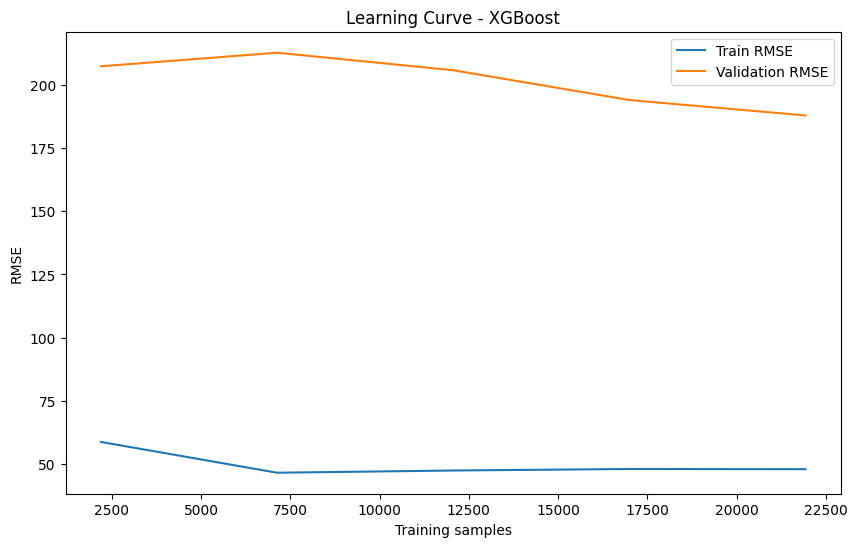

In [73]:
pred_train_xgb_target_wtSC = model_xgb_target_wtSC.predict(X_train_target_wtSC)
pred_val_xgb_target_wtSC = model_xgb_target_wtSC.predict(X_val_target_wtSC)
gap_xgb_target_wtSC = evaluate_gap(y_train, pred_train_xgb_target_wtSC, y_val, pred_val_xgb_target_wtSC, "XGBoost")
addmet_xgb_target_wtSC = evaluate_additional_metrics(y_val, pred_val_xgb_target_wtSC, "XGBoost")
cv_xgb_wtSC = cross_val_xgb(
    study_xgb_target_wtSC.best_params,
    X_train_target_wtSC,
    y_train,
    tscv)
plot_learning_curve(model_xgb_target_wtSC, X_train_target_wtSC, y_train, "XGBoost")


In [74]:
perm_xgb_target_wtSC = permutation_importance(model_xgb_target_wtSC, X_val_target_wtSC, y_val, random_state=42, n_repeats=10)
#Load study 
#perm_xgb_target_wtSC= joblib.load('/kaggle/input/datasets/davibaca/study-xgb/permutation_result_xgb_target.pkl')
feature_importances = pd.DataFrame({
    'feature': X_val_target_wtSC.columns,
    'importance_mean': perm_xgb_target_wtSC.importances_mean,
    'importance_std': perm_xgb_target_wtSC.importances_std
}).sort_values(by='importance_mean', ascending=False)

joblib.dump(perm_xgb_target_wtSC, f'{Output_directory}permutation_result_xgb_target_wtSC.pkl')

print(feature_importances)

                         feature  importance_mean  importance_std
0  country_store_product_encoded         0.598470        0.002625
1            target_enc__country         0.175067        0.000799
3            target_enc__product         0.156206        0.000993
2              target_enc__store         0.070846        0.001076
4                      dayofweek         0.030615        0.000535
7                      dayofyear         0.008053        0.000126
8                     weekofyear         0.006946        0.000120
5                          month         0.001917        0.000045
6                           year         0.000000        0.000000


In [75]:
# 1. XGBoost with only target encoding without firs and second level interaction

X_train_target_wtFC = X_train.drop(['target_enc__store', 'target_enc__country', 'target_enc__product','country_store_encoded',
                                    'store_product_encoded', 'country_product_encoded','country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()

X_val_target_wtFC = X_val.drop(['target_enc__store', 'target_enc__country', 'target_enc__product','country_store_encoded',
                                    'store_product_encoded', 'country_product_encoded','country_Canada', 'country_Finland','country_Italy',
                                                   'country_Kenya', 'country_Norway', 'country_Singapore',
                                                   'store_Discount Stickers', 'store_Premium Sticker Mart',
                                                   'store_Stickers for Less', 'product_Holographic Goose', 'product_Kaggle',
                                                   'product_Kaggle Tiers', 'product_Kerneler', 'product_Kerneler Dark Mode'], axis=1).copy()
    

In [76]:
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 100),
        'gamma': trial.suggest_float('gamma', 0.01, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.2, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 20.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 10, 100.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_target_wtFC)):
        X_tr, X_va = X_train_target_wtFC.iloc[train_idx], X_train_target_wtFC.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

study_xgb_target_wtFC = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
study_xgb_target_wtFC.optimize(objective_xgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
print(f"XGBoost best parameters: {study_xgb_target_wtFC.best_params}")

# saves the study
joblib.dump(study_xgb_target_wtFC, f'{Output_directory}study_xgb_target_wtFC.pkl')

#Load study 
#study_xgb_target = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/study_xgb_target.pkl')

[I 2026-09-17 11:53:33,721] A new study created in memory with name: no-name-13acc227-2f1f-4322-837d-57195338f0d9
[I 2026-09-17 11:54:11,797] Trial 0 finished with value: 260.94785392726203 and parameters: {'n_estimators': 2105, 'learning_rate': 0.012866742758077603, 'max_depth': 2, 'min_child_weight': 91, 'gamma': 0.6596099207886096, 'subsample': 0.5045985258083148, 'colsample_bytree': 0.4608829257196193, 'colsample_bylevel': 0.7308014152864446, 'reg_alpha': 0.0010514049659988579, 'reg_lambda': 14.481316698225731}. Best is trial 0 with value: 260.94785392726203.
[I 2026-09-17 11:54:18,040] Trial 1 finished with value: 254.86868430600225 and parameters: {'n_estimators': 1872, 'learning_rate': 0.0794650948407619, 'max_depth': 4, 'min_child_weight': 30, 'gamma': 1.3694231460024369, 'subsample': 0.6186245437484, 'colsample_bytree': 0.5952398188955607, 'colsample_bylevel': 0.7971931240944194, 'reg_alpha': 0.6224300978555493, 'reg_lambda': 70.66809927935715}. Best is trial 1 with value: 254

No improvement in the last 60 trials. Stopping study.
XGBoost best parameters: {'n_estimators': 1192, 'learning_rate': 0.10845941265321238, 'max_depth': 4, 'min_child_weight': 10, 'gamma': 0.0154760228652556, 'subsample': 0.9950721579214219, 'colsample_bytree': 0.9260628126151419, 'colsample_bylevel': 0.9298243225751642, 'reg_alpha': 8.576407362931558, 'reg_lambda': 79.29129291566424}


['/kaggle/working/study_xgb_target_wtFC.pkl']

In [77]:
#Creat a dataframe to fit de model with the best params
# 80% for training
split = int(len(X_train_target_wtFC) * 0.8)

df_train = X_train_target_wtFC.iloc[:split].copy()
y_tr = y_train.iloc[:split].copy()

# 20% early stopping
df_val = X_train_target_wtFC.iloc[split:].copy()
y_va = y_train.iloc[split:].copy()   

model_xgb_target_wtFC = xgb.XGBRegressor(**study_xgb_target_wtFC.best_params, random_state=42, early_stopping_rounds=30)
model_xgb_target_wtFC.fit(df_train, y_tr, eval_set=[(df_val, y_va)],verbose=False)
joblib.dump(model_xgb_target_wtFC, f'{Output_directory}model_xgb_target_wtFC.pkl')

#Load study 
#model_xgb_target = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/model_xgb_target.pkl')

['/kaggle/working/model_xgb_target_wtFC.pkl']

--- XGBoost: Train vs Val ---
RMSE train: 276.6687 | RMSE val: 190.5779
Gap: -86.0908 (-31.12%)
--- XGBoost: Additional metrics ---
MAE: 111.4075 | MAPE: 793763749544263040.00% | R²: 0.9118 | RMSLE: N/A (negative predictions)
Bias (mean error): -63.6112
Prediction std: 722.1568 | Real std: 641.8150
Within ±10%: 34.22%
Within ±15%: 47.52%
Within ±20%: 57.71%
Fold 1: 524.5149
Fold 2: 155.2037
Fold 3: 144.8074
Fold 4: 128.4231
Fold 5: 119.5150
CV mean: 214.4928
CV std: 155.5080


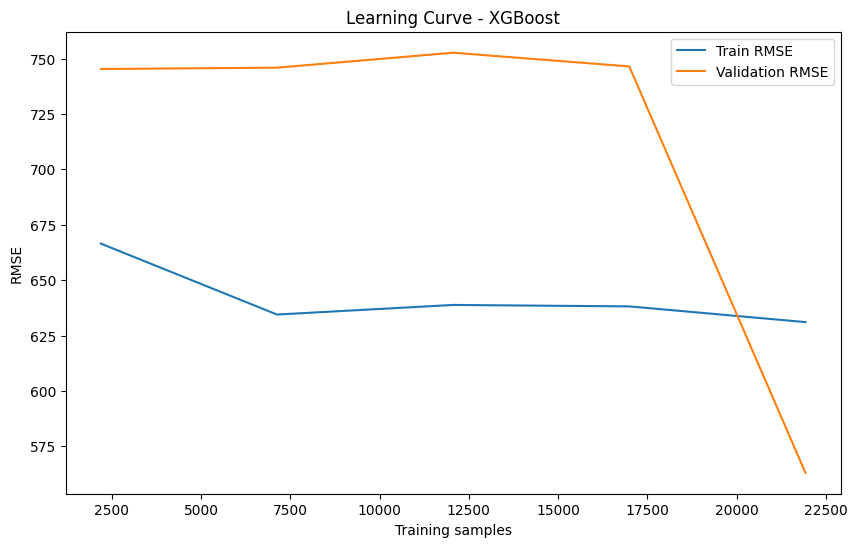

In [78]:
pred_train_xgb_target_wtFC = model_xgb_target_wtFC.predict(X_train_target_wtFC)
pred_val_xgb_target_wtFC = model_xgb_target_wtFC.predict(X_val_target_wtFC)
gap_xgb_target_wtFC = evaluate_gap(y_train, pred_train_xgb_target_wtFC, y_val, pred_val_xgb_target_wtFC, "XGBoost")
addmet_xgb_target_wtFC = evaluate_additional_metrics(y_val, pred_val_xgb_target_wtFC, "XGBoost")
cv_xgb_wtFC = cross_val_xgb(
    study_xgb_target_wtFC.best_params,
    X_train_target_wtFC,
    y_train,
    tscv)
plot_learning_curve(model_xgb_target_wtFC, X_train_target_wtFC, y_train, "XGBoost")


In [79]:
perm_xgb_target_wtFC = permutation_importance(model_xgb_target_wtFC, X_val_target_wtFC, y_val, random_state=42, n_repeats=10)
#Load study 
#perm_xgb_target_wtFC= joblib.load('/kaggle/input/datasets/davibaca/study-xgb/permutation_result_xgb_target.pkl')
feature_importances = pd.DataFrame({
    'feature': X_val_target_wtFC.columns,
    'importance_mean': perm_xgb_target_wtFC.importances_mean,
    'importance_std': perm_xgb_target_wtFC.importances_std
}).sort_values(by='importance_mean', ascending=False)

joblib.dump(perm_xgb_target_wtFC, f'{Output_directory}permutation_result_xgb_target_wtFC.pkl')

print(feature_importances)

                         feature  importance_mean  importance_std
0  country_store_product_encoded         2.167473        0.009301
1                      dayofweek         0.029343        0.000546
4                      dayofyear         0.001676        0.000080
5                     weekofyear         0.001597        0.000076
2                          month         0.000117        0.000016
3                           year         0.000000        0.000000


In [80]:
#Onehot encoding dataframe
X_train_onehot = X_train.drop(['target_enc__store',
                                                  'target_enc__country', 'target_enc__product','country_store_encoded', 'store_product_encoded',
                                                  'country_product_encoded', 'country_store_product_encoded'], axis=1).copy()


X_val_onehot = X_val.drop(['target_enc__store',
                           'target_enc__country', 'target_enc__product','country_store_encoded', 'store_product_encoded',
                           'country_product_encoded', 'country_store_product_encoded'], axis=1).copy()

In [81]:
# 1. XGBoost with only onehot encoding 
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 100),
        'gamma': trial.suggest_float('gamma', 0.01, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.2, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 20.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 10, 100.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_onehot)):
        X_tr, X_va = X_train_onehot.iloc[train_idx], X_train_onehot.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

study_xgb_onehot = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
study_xgb_onehot.optimize(objective_xgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
print(f"XGBoost best parameters: {study_xgb_onehot.best_params}")

# saves the study
joblib.dump(study_xgb_onehot, f'{Output_directory}study_xgb_onehot.pkl')

#Load study 
#study_xgb_onehot = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/study_xgb_target.pkl')

[I 2026-09-17 12:00:29,922] A new study created in memory with name: no-name-aff5fb4a-baea-4a56-98c0-71166149db5e
[I 2026-09-17 12:00:53,147] Trial 0 finished with value: 124.97398408070094 and parameters: {'n_estimators': 629, 'learning_rate': 0.04912565048295845, 'max_depth': 4, 'min_child_weight': 68, 'gamma': 1.5075579010793654, 'subsample': 0.9879260397312672, 'colsample_bytree': 0.7097802089807173, 'colsample_bylevel': 0.4583651783529968, 'reg_alpha': 2.630992898414733, 'reg_lambda': 18.656589301678114}. Best is trial 0 with value: 124.97398408070094.
[I 2026-09-17 12:01:54,174] Trial 1 finished with value: 225.6223572142951 and parameters: {'n_estimators': 1597, 'learning_rate': 0.012649521731184974, 'max_depth': 2, 'min_child_weight': 97, 'gamma': 3.220626495993124, 'subsample': 0.847987103046849, 'colsample_bytree': 0.6453717666485619, 'colsample_bylevel': 0.33863545605667666, 'reg_alpha': 0.004708042915737182, 'reg_lambda': 17.792742686803432}. Best is trial 0 with value: 124

XGBoost best parameters: {'n_estimators': 1501, 'learning_rate': 0.18070843802170816, 'max_depth': 5, 'min_child_weight': 95, 'gamma': 7.557863550006301, 'subsample': 0.9079923010403638, 'colsample_bytree': 0.6224875518708561, 'colsample_bylevel': 0.7076453463213802, 'reg_alpha': 0.0011368434836476246, 'reg_lambda': 62.546507276237854}


['/kaggle/working/study_xgb_onehot.pkl']

In [82]:
print(f"Trials executed: {len(study_xgb_onehot.trials)}")
print(f"Best trial: {study_xgb_onehot.best_trial.number}")
print(f"Best RMSE: {study_xgb_onehot.best_value:.4f}")
print(f"Best parameters: {study_xgb_onehot.best_params}")

Trials executed: 200
Best trial: 183
Best RMSE: 115.9432
Best parameters: {'n_estimators': 1501, 'learning_rate': 0.18070843802170816, 'max_depth': 5, 'min_child_weight': 95, 'gamma': 7.557863550006301, 'subsample': 0.9079923010403638, 'colsample_bytree': 0.6224875518708561, 'colsample_bylevel': 0.7076453463213802, 'reg_alpha': 0.0011368434836476246, 'reg_lambda': 62.546507276237854}


In [83]:
### Creat a dataframe to fit de model with the best params
# 80% for training
split = int(len(X_train_onehot) * 0.8)

df_train = X_train_onehot.iloc[:split].copy()
y_tr = y_train.iloc[:split].copy()

# 20% early stopping
df_val = X_train_onehot.iloc[split:].copy()
y_va = y_train.iloc[split:].copy()   

model_xgb_onehot = xgb.XGBRegressor(**study_xgb_onehot.best_params, random_state=42, early_stopping_rounds=30)
model_xgb_onehot.fit(df_train, y_tr, eval_set=[(df_val, y_va)],verbose=False)
joblib.dump(model_xgb_onehot, f'{Output_directory}model_xgb_onehot.pkl')

#Load study 
#model_xgb_onehot = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/model_xgb_onehot.pkl')

['/kaggle/working/model_xgb_onehot.pkl']

--- XGBoost: Train vs Val ---
RMSE train: 77.7299 | RMSE val: 177.3704
Gap: 99.6405 (128.19%)
--- XGBoost: Additional metrics ---
MAE: 96.8096 | MAPE: 865889767538881664.00% | R²: 0.9236 | RMSLE: N/A (negative predictions)
Bias (mean error): -55.8586
Prediction std: 722.1146 | Real std: 641.8150
Within ±10%: 43.57%
Within ±15%: 57.75%
Within ±20%: 66.81%
Fold 1: 159.7253
Fold 2: 113.4275
Fold 3: 108.2019
Fold 4: 97.3475
Fold 5: 101.0136
CV mean: 115.9432
CV std: 22.5913


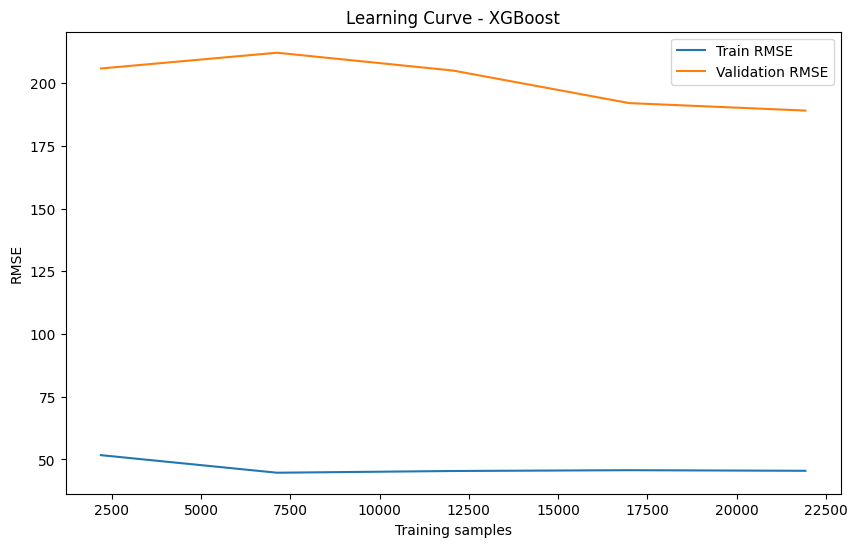

In [84]:
pred_train_xgb_onehot = model_xgb_onehot.predict(X_train_onehot)
pred_val_xgb_onehot = model_xgb_onehot.predict(X_val_onehot)
gap_xgb_onehot = evaluate_gap(y_train, pred_train_xgb_onehot, y_val, pred_val_xgb_onehot, "XGBoost")
addmet_xgb_onehot = evaluate_additional_metrics(y_val, pred_val_xgb_onehot, "XGBoost")
cv_xgb = cross_val_xgb(
    study_xgb_onehot.best_params,
    X_train_onehot,
    y_train,
    tscv)
plot_learning_curve(model_xgb_onehot, X_train_onehot, y_train, "XGBoost")


In [85]:
perm_xgb_onehot = permutation_importance(model_xgb_onehot, X_val_onehot, y_val, random_state=42, n_repeats=10)
#Load study 
#perm_xgb_onehot = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/permutation_result_xgb_onehot.pkl')
feature_importances= pd.DataFrame({
    'feature': X_val_onehot.columns,
    'importance_mean': perm_xgb_onehot.importances_mean,
    'importance_std': perm_xgb_onehot.importances_std
}).sort_values(by='importance_mean', ascending=False)

joblib.dump(perm_xgb_onehot, f'{Output_directory}permutation_result_xgb_onehot.pkl')

print(feature_importances)

                       feature  importance_mean  importance_std
14   product_Holographic Goose         0.508341        0.001931
8                country_Kenya         0.441337        0.001890
9               country_Norway         0.397675        0.002113
11     store_Discount Stickers         0.260452        0.002047
15              product_Kaggle         0.110406        0.000833
17            product_Kerneler         0.108873        0.000991
18  product_Kerneler Dark Mode         0.060747        0.000589
12  store_Premium Sticker Mart         0.033998        0.000899
7                country_Italy         0.029716        0.000220
0                    dayofweek         0.029301        0.000485
10           country_Singapore         0.019661        0.000109
16        product_Kaggle Tiers         0.013503        0.000225
3                    dayofyear         0.009416        0.000177
4                   weekofyear         0.004639        0.000079
1                        month         0

In [86]:
#Onehot encoding dataframe
X_train_onehot_tr = X_train.drop(['target_enc__store',
                                                  'target_enc__country', 'target_enc__product','country_store_encoded', 'store_product_encoded',
                                                  'country_product_encoded'], axis=1).copy()


X_val_onehot_tr = X_val.drop(['target_enc__store',
                           'target_enc__country', 'target_enc__product','country_store_encoded', 'store_product_encoded',
                           'country_product_encoded'], axis=1).copy()

In [87]:
# XGBoost with only onehot encoding and triple interaction of target encoding
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 100),
        'gamma': trial.suggest_float('gamma', 0.01, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.2, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 20.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 10, 100.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_onehot_tr)):
        X_tr, X_va = X_train_onehot_tr.iloc[train_idx], X_train_onehot_tr.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        pred = model.predict(X_va)
        rmse = root_mean_squared_error(y_va, pred)
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

study_xgb_onehot_tr = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
study_xgb_onehot_tr.optimize(objective_xgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
print(f"XGBoost best parameters: {study_xgb_onehot_tr.best_params}")

# saves the study
joblib.dump(study_xgb_onehot_tr, f'{Output_directory}study_xgb_onehot_tr.pkl')

#Load study 
#study_xgb_onehot = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/study_xgb_target.pkl')

[I 2026-09-17 12:30:48,970] A new study created in memory with name: no-name-ec3ba99f-859f-4c12-be4c-2edfb6f56fcc
[I 2026-09-17 12:31:02,917] Trial 0 finished with value: 133.0572060643482 and parameters: {'n_estimators': 757, 'learning_rate': 0.1493648490347593, 'max_depth': 4, 'min_child_weight': 85, 'gamma': 0.09123233767937085, 'subsample': 0.9477616142481002, 'colsample_bytree': 0.6335210072404979, 'colsample_bylevel': 0.2086701211842387, 'reg_alpha': 7.83565016719382, 'reg_lambda': 12.339190715949712}. Best is trial 0 with value: 133.0572060643482.
[I 2026-09-17 12:31:11,859] Trial 1 finished with value: 128.35150358519127 and parameters: {'n_estimators': 1298, 'learning_rate': 0.17221029744955266, 'max_depth': 5, 'min_child_weight': 62, 'gamma': 0.7861612553123299, 'subsample': 0.7242227609891598, 'colsample_bytree': 0.5759264630188388, 'colsample_bylevel': 0.4629316362959328, 'reg_alpha': 0.7807680842896021, 'reg_lambda': 56.54243786287024}. Best is trial 1 with value: 128.3515

XGBoost best parameters: {'n_estimators': 1665, 'learning_rate': 0.019740580769697667, 'max_depth': 5, 'min_child_weight': 81, 'gamma': 0.2330830040843327, 'subsample': 0.8399787650789182, 'colsample_bytree': 0.5643493830769696, 'colsample_bylevel': 0.6166083125461206, 'reg_alpha': 4.24263969367674, 'reg_lambda': 64.88131790578863}


['/kaggle/working/study_xgb_onehot_tr.pkl']

In [88]:
print(f"Trials executed: {len(study_xgb_onehot_tr.trials)}")
print(f"Best trial: {study_xgb_onehot_tr.best_trial.number}")
print(f"Best RMSE: {study_xgb_onehot_tr.best_value:.4f}")
print(f"Best parameters: {study_xgb_onehot_tr.best_params}")

Trials executed: 200
Best trial: 154
Best RMSE: 125.8196
Best parameters: {'n_estimators': 1665, 'learning_rate': 0.019740580769697667, 'max_depth': 5, 'min_child_weight': 81, 'gamma': 0.2330830040843327, 'subsample': 0.8399787650789182, 'colsample_bytree': 0.5643493830769696, 'colsample_bylevel': 0.6166083125461206, 'reg_alpha': 4.24263969367674, 'reg_lambda': 64.88131790578863}


In [89]:
### Creat a dataframe to fit de model with the best params
# 80% for training
split = int(len(X_train_onehot_tr) * 0.8)

df_train = X_train_onehot_tr.iloc[:split].copy()
y_tr = y_train.iloc[:split].copy()

# 20% early stopping
df_val = X_train_onehot_tr.iloc[split:].copy()
y_va = y_train.iloc[split:].copy()   

model_xgb_onehot_tr = xgb.XGBRegressor(**study_xgb_onehot_tr.best_params, random_state=42, early_stopping_rounds=30)
model_xgb_onehot_tr.fit(df_train, y_tr, eval_set=[(df_val, y_va)],verbose=False)
joblib.dump(model_xgb_onehot_tr, f'{Output_directory}model_xgb_onehot_tr.pkl')

#Load study 
#model_xgb_onehot = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/model_xgb_onehot.pkl')

['/kaggle/working/model_xgb_onehot_tr.pkl']

--- XGBoost: Train vs Val ---
RMSE train: 95.6318 | RMSE val: 182.4594
Gap: 86.8276 (90.79%)
--- XGBoost: Additional metrics ---
MAE: 99.7878 | MAPE: 1008867153228380160.00% | R²: 0.9192 | RMSLE: N/A (negative predictions)
Bias (mean error): -63.6065
Prediction std: 723.9376 | Real std: 641.8150
Within ±10%: 43.54%
Within ±15%: 57.42%
Within ±20%: 66.22%
Fold 1: 159.4712
Fold 2: 123.3702
Fold 3: 133.4943
Fold 4: 108.3068
Fold 5: 104.4555
CV mean: 125.8196
CV std: 19.8013


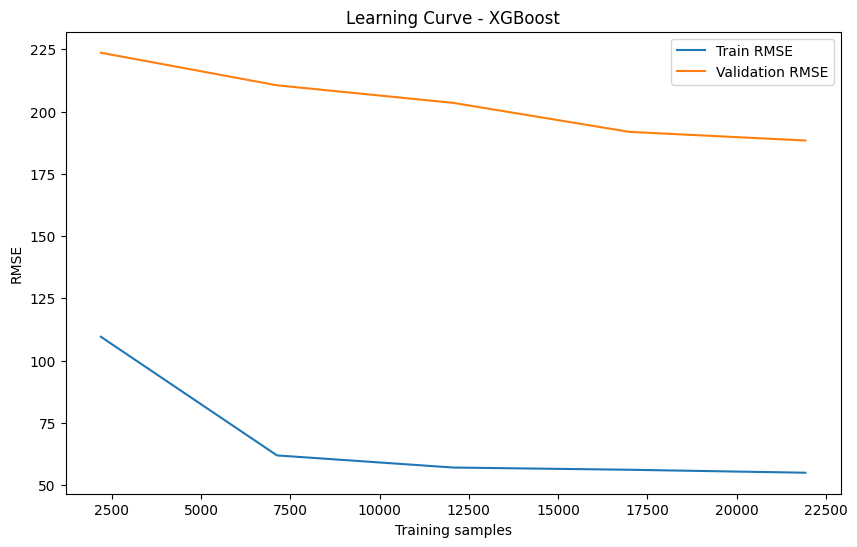

In [90]:
pred_train_xgb_onehot_tr = model_xgb_onehot_tr.predict(X_train_onehot_tr)
pred_val_xgb_onehot_tr = model_xgb_onehot_tr.predict(X_val_onehot_tr)
gap_xgb_onehot_tr = evaluate_gap(y_train, pred_train_xgb_onehot_tr, y_val, pred_val_xgb_onehot_tr, "XGBoost")
addmet_xgb_onehot_tr = evaluate_additional_metrics(y_val, pred_val_xgb_onehot_tr, "XGBoost")
cv_xgb_tr = cross_val_xgb(
    study_xgb_onehot_tr.best_params,
    X_train_onehot_tr,
    y_train,
    tscv)
plot_learning_curve(model_xgb_onehot_tr, X_train_onehot_tr, y_train, "XGBoost")


In [91]:
perm_xgb_onehot_tr = permutation_importance(model_xgb_onehot_tr, X_val_onehot_tr, y_val, random_state=42, n_repeats=10)
#Load study 
#perm_xgb_onehot = joblib.load('/kaggle/input/datasets/davibaca/study-xgb/permutation_result_xgb_onehot.pkl')
feature_importances= pd.DataFrame({
    'feature': X_val_onehot_tr.columns,
    'importance_mean': perm_xgb_onehot_tr.importances_mean,
    'importance_std': perm_xgb_onehot_tr.importances_std
}).sort_values(by='importance_mean', ascending=False)

joblib.dump(perm_xgb_onehot_tr, f'{Output_directory}permutation_result_xgb_onehot_tr.pkl')

print(feature_importances)

                          feature  importance_mean  importance_std
0   country_store_product_encoded         0.392281        0.001422
9                   country_Kenya         0.111383        0.000729
15      product_Holographic Goose         0.085464        0.000529
10                 country_Norway         0.062732        0.000843
12        store_Discount Stickers         0.054212        0.000719
16                 product_Kaggle         0.047795        0.000452
1                       dayofweek         0.029027        0.000525
13     store_Premium Sticker Mart         0.009758        0.000394
18               product_Kerneler         0.009008        0.000206
17           product_Kaggle Tiers         0.007755        0.000185
11              country_Singapore         0.007465        0.000041
19     product_Kerneler Dark Mode         0.003859        0.000066
8                   country_Italy         0.003367        0.000126
4                       dayofyear         0.003135        0.00